---
# Part 1 - Results from the GS's are Analyzed 
---
- purpose of the Part 1 of thenotebook is to analyze the metrics from an initial exploratory gridsearch 
- after this largetr GS, i run a more concentrated GS with less parameters , parameters are eliminated based on the visual analysis below 
- more robust methods may be used but this works for now 

In [2]:
import pandas as pd
import pickle
import random
import numpy as np
import os
import itertools
from joblib import Parallel, delayed , parallel_backend
from collections import defaultdict
import math
import torch.nn as nn
import json
import matplotlib.pyplot as plt
import random
from Equations_Run_Combo_V_2 import *


import pickle
with open('/Users/cs/Desktop/LSTM_ETF/short_dfs.pkl', 'rb') as f:
    loaded_dfs = pickle.load(f)

with open("/Users/cs/Desktop/LSTM_ETF/lagged_cache.pkl", "rb") as f:
    lagged_cache = pickle.load(f)


from Functions_1_Initial_GS_and_Dist_Analytics_HOD_20_01_21_12 import *

#/home/charifslmn/

In [3]:

import json

import copy

with open('/Users/cs/Desktop/top_70_DIST_DISC_GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json') as f_json:
    results_dist_disc = json.load(f_json)   # Load the JSON data
    

with open('/Users/cs/Desktop/Tset_70_models_GS_21_01_to_22_12_DIST_Discovery_10percentPOS_Vset_HOD.json') as f:
    results_dist_disc_Tset_loaded = json.load(f)

results_dist_disc_Tset = copy.deepcopy(results_dist_disc_Tset_loaded)

ignore = ['val_start_month', 'val_end_month' , 'seed_num']

for true in results_dist_disc: ### make sure the combo idx lines up, parallel_backend runs could vary since its the idx when func is called in parallel 
    t_cb_idx = true["combo_index"]
    tt = str({k: v for k, v in true['combo'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset:
        f_cb_idx = find["combo_index"]
        ff = str({k: v for k, v in find['combo'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

        if tt == ff:
            # print(tt)
            find['combo_index'] = t_cb_idx






In [4]:


###### T set with same seed sas val set, neeed sot be organized first 

with open('/Users/cs/Desktop/Tset_NOTsorted_70_models_GS_21_01_to_22_12_DIST_Discovery_10percentPOS_HOD.json') as f:
    results_dist_disc_Tset_NOTsorted_same_seeds = json.load(f)


# ignore = ['val_start_month', 'val_end_month' , 'seed']


##### Organizing the results to have same seeds and combos together --- since params were extracted themselves for GC run simplification 
results_dist_disc_Tset_same_seeds = copy.deepcopy(results_dist_disc_Tset_NOTsorted_same_seeds)

ignore_find_combo = ['val_start_month', 'val_end_month'  ]
### first collect combo_idxs and combo outer info
results_dist_disc_Tset_same_seeds_organized = []
for true in results_dist_disc: ### make sure the combo idx lines up, parallel_backend runs could vary since its the idx when func is called in parallel 
    t_cb_idx = true["combo_index"]

    # same_seed_and_combo = []
    dict_entry = {}
    tt = str({k: v for k, v in true['combo'].items() if k not in ignore_find_combo}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset_same_seeds:

        ff = str({k: v for k, v in find['parameters'].items() if k not in ignore_find_combo}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')
        if tt == ff:
            dict_entry["combo_index"] = t_cb_idx
            dict_entry["combo"] = find["parameters"]
            results_dist_disc_Tset_same_seeds_organized.append(dict_entry)
            break
        

ignore_find_seeds = ['val_start_month', 'val_end_month'  , 'seed_num'   ]

### then collect per seed results for each combo , combos are
for entry in results_dist_disc_Tset_same_seeds_organized:
    entry["per_seed_all_results"] = []

    ee = str({k: v for k, v in entry['combo'].items() if k not in ignore_find_seeds}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset_same_seeds:
        ff = str({k: v for k, v in find['parameters'].items() if k not in ignore_find_seeds}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

        if ee == ff:
            seed_entry = {}
            # print(find["parameters"]["seed_num"])
            seed_entry["seed"] = find["parameters"]["seed_num"]
            seed_entry["result_entry"] = find
            entry["per_seed_all_results"].append(seed_entry)

##### Organizing the results to have same seeds and combos together

            

In [5]:
brackets = [(0.5, 0.6), (0.6, 0.65), (0.65, 0.7), (0.7, 0.75), 
            (0.75, 0.8), (0.8, 0.85), (0.85, 0.9), (0.9, 0.95), (0.95, 1)]

metrics = ["precision_up", "recall_up", "accuracy"]


# ---- collect per-model data and compute precision_up mean for ordering ----
model_summaries = []  # (prec_mean, combo_idx, collected_dict, parameters, per_seed)

for model in results_dist_disc:
    combo_idx = model["combo_index"]
    parameters = model["combo"]
    per_seed = model["per_seed_all_results"]

    collected = {k: [] for k in metrics}
    for run in per_seed:
        om = run["result_entry"]["cv_sets"]["overall_metrics"]
        for k in metrics:
            v = om[k]
            try:
                collected[k].append(float(v))
            except (TypeError, ValueError):
                collected[k].append(None)

    vals_prec = [x for x in collected["precision_up"] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
    prec_mean = float(np.mean(vals_prec)) if vals_prec else float("nan")


    model_summaries.append((prec_mean, combo_idx, collected, parameters, per_seed))

# sort as before
model_summaries.sort(key=lambda t: (-t[0]) if not math.isnan(t[0]) else float("inf"))


##############################

model_summaries_Tset = []  # (prec_mean, combo_idx, collected_dict, parameters, per_seed)

for model in results_dist_disc_Tset:
    combo_idx = model["combo_index"]
    parameters = model["combo"]
    per_seed = model["per_seed_all_results"]

    collected = {k: [] for k in metrics}
    for run in per_seed:
        om = run["result_entry"]["cv_sets"]["overall_metrics"]
        for k in metrics:
            v = om[k]
            try:
                collected[k].append(float(v))
            except (TypeError, ValueError):
                collected[k].append(None)

    vals_prec = [x for x in collected["precision_up"] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
    prec_mean = float(np.mean(vals_prec)) if vals_prec else float("nan")

    # ⬇️ add per_seed in the tuple
    model_summaries_Tset.append((prec_mean, combo_idx, collected, parameters, per_seed))

# sort as before
model_summaries_Tset.sort(key=lambda t: (-t[0]) if not math.isnan(t[0]) else float("inf"))




##############################

model_summaries_Tset_same_seeds = []  # (prec_mean, combo_idx, collected_dict, parameters, per_seed)

for model in results_dist_disc_Tset_same_seeds_organized:
    combo_idx = model["combo_index"]
    parameters = model["combo"]
    per_seed = model["per_seed_all_results"]

    collected = {k: [] for k in metrics}
    for run in per_seed:
        om = run["result_entry"]["cv_sets"]["overall_metrics"]
        for k in metrics:
            v = om[k]
            try:
                collected[k].append(float(v))
            except (TypeError, ValueError):
                collected[k].append(None)

    vals_prec = [x for x in collected["precision_up"] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
    prec_mean = float(np.mean(vals_prec)) if vals_prec else float("nan")

    # ⬇️ add per_seed in the tuple
    model_summaries_Tset_same_seeds.append((prec_mean, combo_idx, collected, parameters, per_seed))

# sort as before
model_summaries_Tset_same_seeds.sort(key=lambda t: (-t[0]) if not math.isnan(t[0]) else float("inf"))



{'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.05, 'num_epochs': 70, 'batch_size': 10, 'use_bidirectional': False, 'lag': 2, 'input_size': 12, 'hidden_size': 12, 'num_layers': 4, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': False, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 19537, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 0.1, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None, 'use_USO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_UCO_wticoncat_predictor_WEEKLY_END_MO': Fals

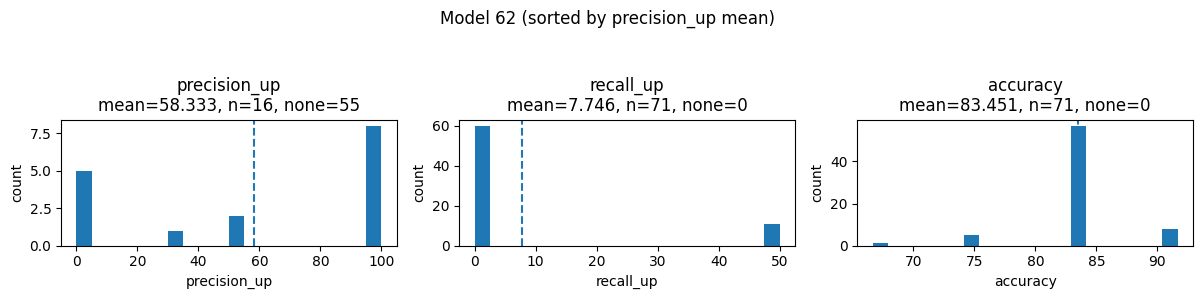

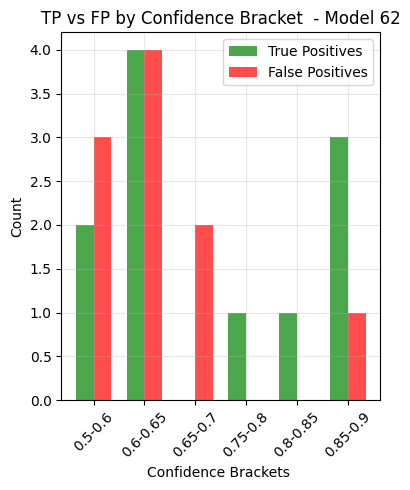

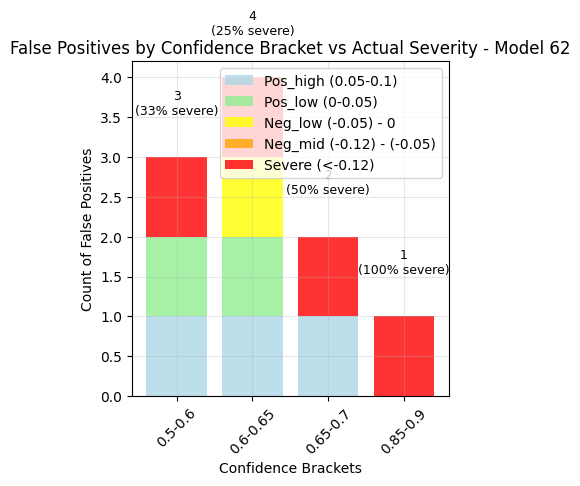

Severe Case Proportions by Confidence Bracket:
--------------------------------------------------
0.5-0.6: 33.3% severe (1/3)
0.6-0.65: 25.0% severe (1/4)
0.65-0.7: 50.0% severe (1/2)
0.85-0.9: 100.0% severe (1/1)
Severity Counts by Confidence Bracket:
--------------------------------------------------
0.5-0.6: {'Pos_high (0.05-0.1)': 1, 'Pos_low (0-0.05)': 1, 'Neg_low (-0.05) - 0': 0, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 1}
0.6-0.65: {'Pos_high (0.05-0.1)': 1, 'Pos_low (0-0.05)': 1, 'Neg_low (-0.05) - 0': 1, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 1}
0.65-0.7: {'Pos_high (0.05-0.1)': 1, 'Pos_low (0-0.05)': 0, 'Neg_low (-0.05) - 0': 0, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 1}
0.85-0.9: {'Pos_high (0.05-0.1)': 0, 'Pos_low (0-0.05)': 0, 'Neg_low (-0.05) - 0': 0, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 1}


In [6]:
import matplotlib.pyplot as plt


LENGTH = 1
# ---- plot in the sorted order ----
for prec_mean, combo_idx, collected, parameters, per_seed in model_summaries_Tset[:LENGTH]:
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), squeeze=False)
    axes = axes[0]

    print(parameters)

    for ax, k in zip(axes, metrics):
        vals = [x for x in collected[k] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
        none_cnt = len(collected[k]) - len(vals)

        if vals:
            mean_val = float(np.mean(vals))
            ax.hist(vals, bins=20)
            ax.axvline(mean_val, linestyle="--")
            ax.set_xlabel(k)
            ax.set_ylabel("count")
            ax.set_title(f"{k}\nmean={mean_val:.3f}, n={len(vals)}, none={none_cnt}")
        else:
            ax.text(0.5, 0.5, f"No data\nnone={none_cnt}", ha="center", va="center")
            ax.set_xticks([]); ax.set_yticks([]); ax.set_title(k)

    fig.suptitle(f"Model {combo_idx} (sorted by precision_up mean)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    # =================== NEW: per-model correlation-threshold + severity plots ===================

    # Recycle your functions by making a "top-like" list from this model's seeds
    # Each item: (score_unused, entry=result_entry)
    top_like_for_this_model = [(0.0, run["result_entry"]) for run in per_seed]

    # Correlation / confidence bracket plot for THIS model
    TP_FP_brackets_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")

    # Severity plot for THIS model
    TP_FP_brackets_severity_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")







{'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.0005, 'num_epochs': 150, 'batch_size': 50, 'use_bidirectional': False, 'lag': 6, 'input_size': 12, 'hidden_size': 55, 'num_layers': 2, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': False, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None, 'use_USO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_UCO_wticoncat_predictor_WEEKLY_END_MO': Fals

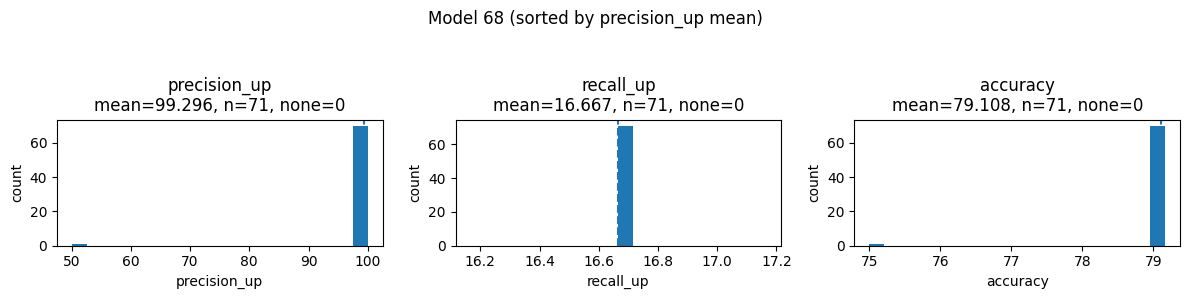

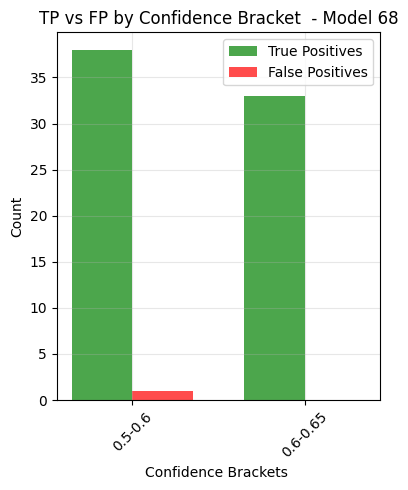

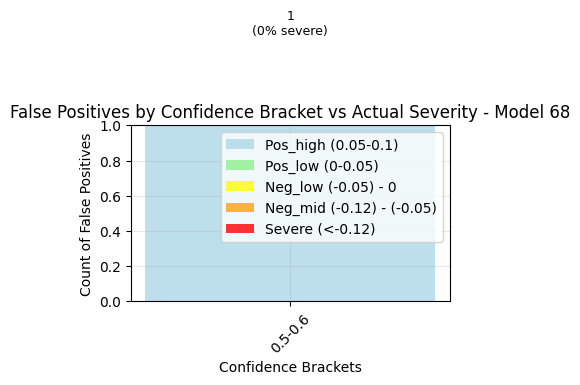

Severe Case Proportions by Confidence Bracket:
--------------------------------------------------
0.5-0.6: 0.0% severe (0/1)
Severity Counts by Confidence Bracket:
--------------------------------------------------
0.5-0.6: {'Pos_high (0.05-0.1)': 1, 'Pos_low (0-0.05)': 0, 'Neg_low (-0.05) - 0': 0, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 0}


In [7]:




LENGTH = 1
# ---- plot in the sorted order ----
for prec_mean, combo_idx, collected, parameters, per_seed in model_summaries[:LENGTH]:
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), squeeze=False)
    axes = axes[0]

    print(parameters)

    for ax, k in zip(axes, metrics):
        vals = [x for x in collected[k] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
        none_cnt = len(collected[k]) - len(vals)

        if vals:
            mean_val = float(np.mean(vals))
            ax.hist(vals, bins=20)
            ax.axvline(mean_val, linestyle="--")
            ax.set_xlabel(k)
            ax.set_ylabel("count")
            ax.set_title(f"{k}\nmean={mean_val:.3f}, n={len(vals)}, none={none_cnt}")
        else:
            ax.text(0.5, 0.5, f"No data\nnone={none_cnt}", ha="center", va="center")
            ax.set_xticks([]); ax.set_yticks([]); ax.set_title(k)

    fig.suptitle(f"Model {combo_idx} (sorted by precision_up mean)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    # =================== NEW: per-model correlation-threshold + severity plots ===================

    # Recycle your functions by making a "top-like" list from this model's seeds
    # Each item: (score_unused, entry=result_entry)
    top_like_for_this_model = [(0.0, run["result_entry"]) for run in per_seed]

    # Correlation / confidence bracket plot for THIS model
    TP_FP_brackets_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")

    # Severity plot for THIS model
    TP_FP_brackets_severity_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")







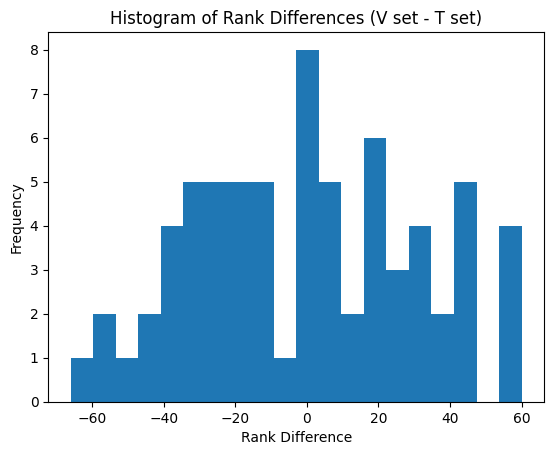

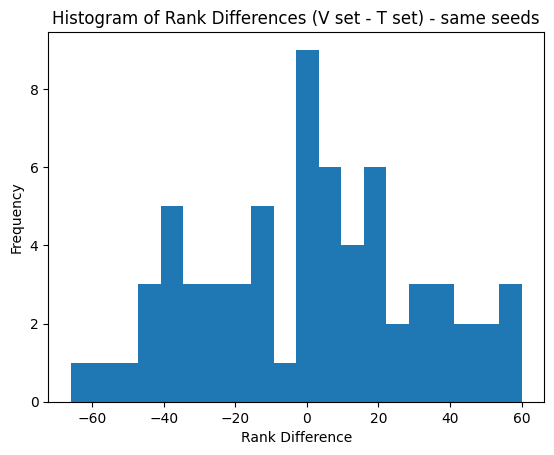

68

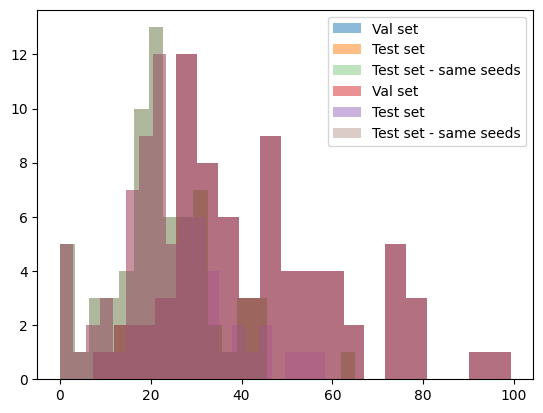

In [8]:


model_summaries_combo_idxs_Tset = [t[1] for t in model_summaries_Tset]
model_summaries_combo_idxs = [t[1] for t in model_summaries]
model_summaries_combo_idxs_Tset_same_seeds = [t[1] for t in model_summaries_Tset_same_seeds]


model_summaries_mean_V = [i[0] for i in model_summaries]
model_summaries_mean_T = [i[0] for i in model_summaries_Tset]
model_summaries_mean_T_same_seeds = [i[0] for i in model_summaries_Tset_same_seeds]


# for i , j in zip(model_summaries_combo_idxs_Tset, model_summaries_combo_idxs):
#  print(i , j)

list_ranks_coupled_V_T = []
for rank , (T_idx , V_idx , T_mean , V_mean) in enumerate(zip( model_summaries_combo_idxs_Tset, model_summaries_combo_idxs , model_summaries_mean_T , model_summaries_mean_V )):
    if not (np.isfinite(T_mean) and np.isfinite(V_mean)):
        continue
    dic = {"rank_V" : rank , "combo_idx_val_V" : V_idx , "rank_T" : rank , "combo_idx_val_T" : T_idx  , "mean_V" : V_mean , "mean_T" : T_mean  }
    list_ranks_coupled_V_T.append(dic)


for out in list_ranks_coupled_V_T:
    for inner in list_ranks_coupled_V_T:
        if out["combo_idx_val_V"] == inner["combo_idx_val_T"]:
            out["rank_diff"] = inner["rank_T"] - out["rank_V"]  
            out["mean_diff"] = inner["mean_T"] - out["mean_V"]
            out["new_mean_T"] = inner["mean_T"]
        
list_ranks_coupled_V_T
rank_diffs = [i["rank_diff"] for i in list_ranks_coupled_V_T]
mean_diffs = [i["mean_diff"] for i in list_ranks_coupled_V_T]

plt.hist(rank_diffs , bins=20)
plt.title("Histogram of Rank Differences (V set - T set)")
plt.xlabel("Rank Difference")
plt.ylabel("Frequency")
plt.show()

###################################### with same seeds

list_ranks_coupled_V_T_same_seeds = []
for rank , (T_idx , V_idx , T_mean , V_mean) in enumerate(zip( model_summaries_combo_idxs_Tset_same_seeds, model_summaries_combo_idxs , model_summaries_mean_T_same_seeds , model_summaries_mean_V )):
    if not (np.isfinite(T_mean) and np.isfinite(V_mean)):
        continue
    dic = {"rank_V" : rank , "combo_idx_val_V" : V_idx , "rank_T" : rank , "combo_idx_val_T" : T_idx  , "mean_V" : V_mean , "mean_T" : T_mean  }
    list_ranks_coupled_V_T_same_seeds.append(dic)


for out in list_ranks_coupled_V_T_same_seeds:
    matched = False
    for inner in list_ranks_coupled_V_T_same_seeds:
        if out["combo_idx_val_V"] == inner["combo_idx_val_T"]:
            out["rank_diff"] = inner["rank_T"] - out["rank_V"]
            out["mean_diff"] = inner["mean_T"] - out["mean_V"]
            out["new_mean_T"] = inner["mean_T"]
            matched = True
            break  # found the pair; no need to keep scanning
    if not matched:
        # no counterpart found → set safe defaults to avoid KeyError later
        out["rank_diff"] = np.nan
        out["mean_diff"] = np.nan
        out["new_mean_T"] = np.nan

rank_diffs = [i["rank_diff"] for i in list_ranks_coupled_V_T_same_seeds]
mean_diffs = [i["mean_diff"] for i in list_ranks_coupled_V_T_same_seeds]


plt.hist(rank_diffs , bins=20)
plt.title("Histogram of Rank Differences (V set - T set) - same seeds")
plt.xlabel("Rank Difference")
plt.ylabel("Frequency")
plt.show()



plt.hist(model_summaries_mean_V , bins=20 , alpha = 0.5 , label = "Val set")
plt.hist(model_summaries_mean_T , bins=20 , alpha = 0.5 , label = "Test set")
plt.hist(model_summaries_mean_T_same_seeds , bins=20 , alpha = 0.3 , label = "Test set - same seeds")
plt.legend()



#### 

plt.hist(model_summaries_mean_V , bins=20 , alpha = 0.5 , label = "Val set")
plt.hist(model_summaries_mean_T , bins=20 , alpha = 0.5 , label = "Test set")
plt.hist(model_summaries_mean_T_same_seeds , bins=20 , alpha = 0.3 , label = "Test set - same seeds")
plt.legend()

len(list_ranks_coupled_V_T_same_seeds)




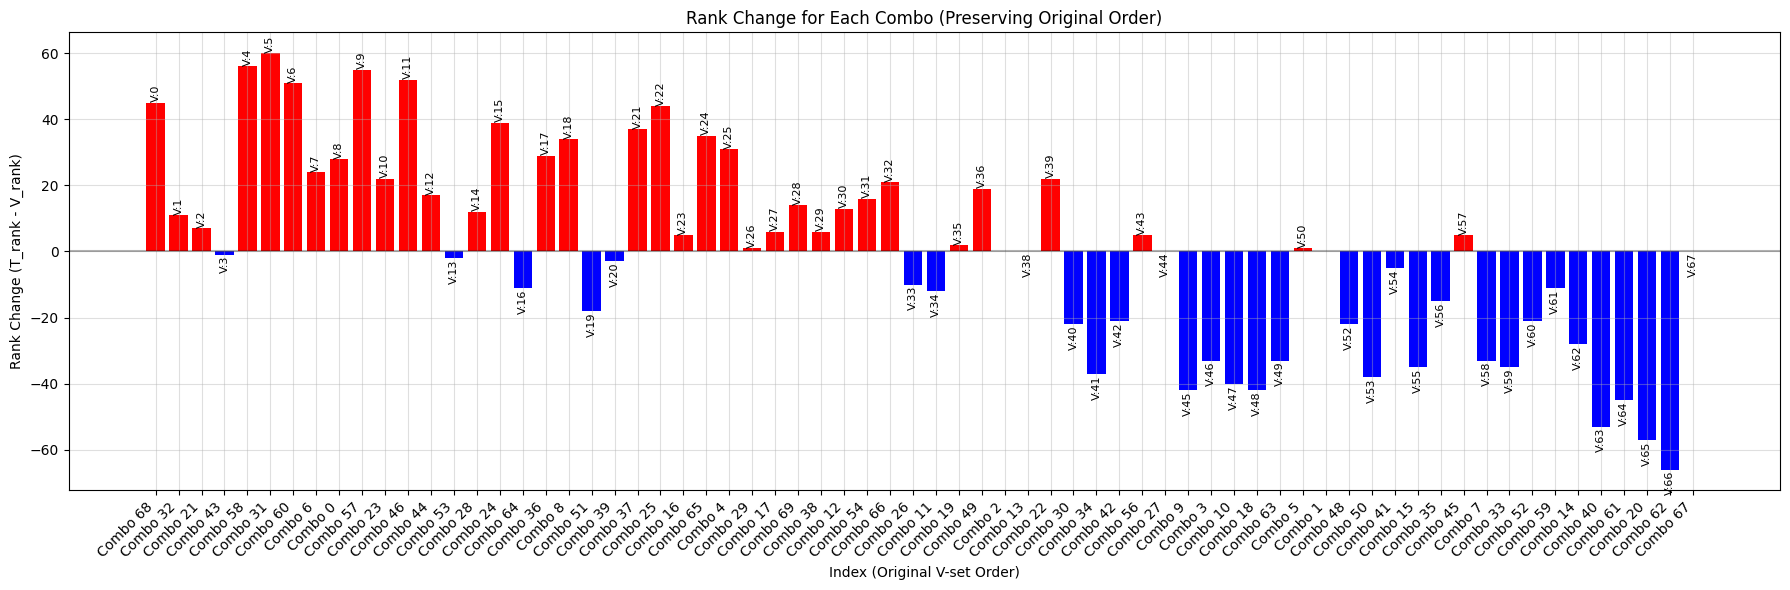

In [9]:
# Use the list_ranks_coupled in the order it was created (same as V set order)
combos = [f"Combo {item['combo_idx_val_V']}" for item in list_ranks_coupled_V_T_same_seeds]
changes = [item["rank_diff"] for item in list_ranks_coupled_V_T_same_seeds]
v_ranks = [item["rank_V"] for item in list_ranks_coupled_V_T_same_seeds]

plt.figure(figsize=(18, 6))
bars = plt.bar(range(len(combos)), changes, 
               color=np.where(np.array(changes) > 0, 'red', 'blue'))

plt.xlabel('Index (Original V-set Order)')
plt.ylabel('Rank Change (T_rank - V_rank)')
plt.title('Rank Change for Each Combo (Preserving Original Order)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add V rank labels for reference
for i, (bar, v_rank) in enumerate(zip(bars, v_ranks)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.1 if bar.get_height() > 0 else -0.4), 
             f'V:{v_rank}', ha='center', va='bottom' if bar.get_height() > 0 else 'top', 
             fontsize=8, rotation=90)
plt.grid(True , alpha=0.4)
plt.xticks(range(len(combos)), combos, rotation=45, ha='right')
plt.tight_layout()
plt.show()

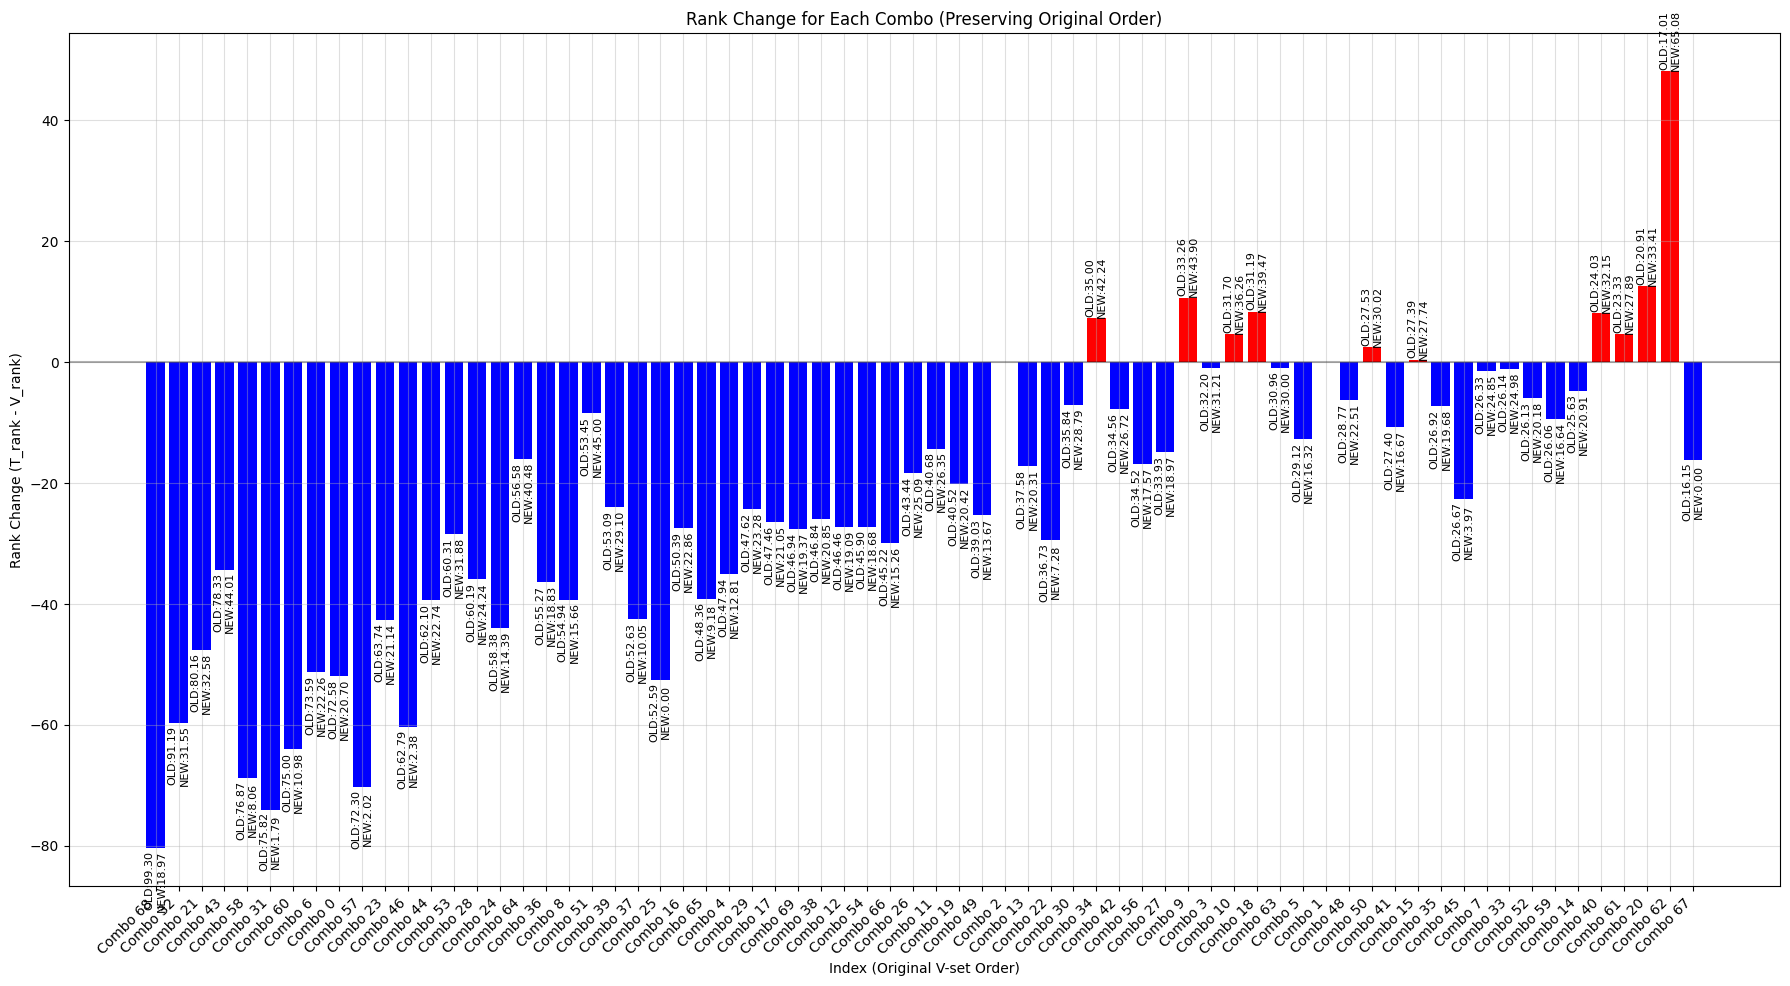

In [10]:
# Use the list_ranks_coupled in the order it was created (same as V set order)
combos = [f"Combo {item['combo_idx_val_V']}" for item in list_ranks_coupled_V_T_same_seeds]
changes = [item["mean_diff"] for item in list_ranks_coupled_V_T_same_seeds]
v_ranks = [item["rank_V"] for item in list_ranks_coupled_V_T_same_seeds]
v_mean = [item["mean_V"] for item in list_ranks_coupled_V_T_same_seeds]
v_new_mean = [item["new_mean_T"] for item in list_ranks_coupled_V_T_same_seeds]

plt.figure(figsize=(18, 10))
bars = plt.bar(range(len(combos)), changes, 
               color=np.where(np.array(changes) > 0, 'red', 'blue'))

plt.xlabel('Index (Original V-set Order)')
plt.ylabel('Rank Change (T_rank - V_rank)')
plt.title('Rank Change for Each Combo (Preserving Original Order)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add V rank labels for reference
for i, (bar, v_rank, v_mean_val, v_new_mean_val) in enumerate(zip(bars, v_ranks , v_mean , v_new_mean)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.1 if bar.get_height() > 0 else -0.4), 
             f'OLD:{v_mean_val:.2f}\nNEW:{v_new_mean_val:.2f}', ha='center', va='bottom' if bar.get_height() > 0 else 'top', 
             fontsize=8, rotation=90)
plt.grid(True , alpha=0.4)
plt.xticks(range(len(combos)), combos, rotation=45, ha='right')
plt.tight_layout()
plt.show()

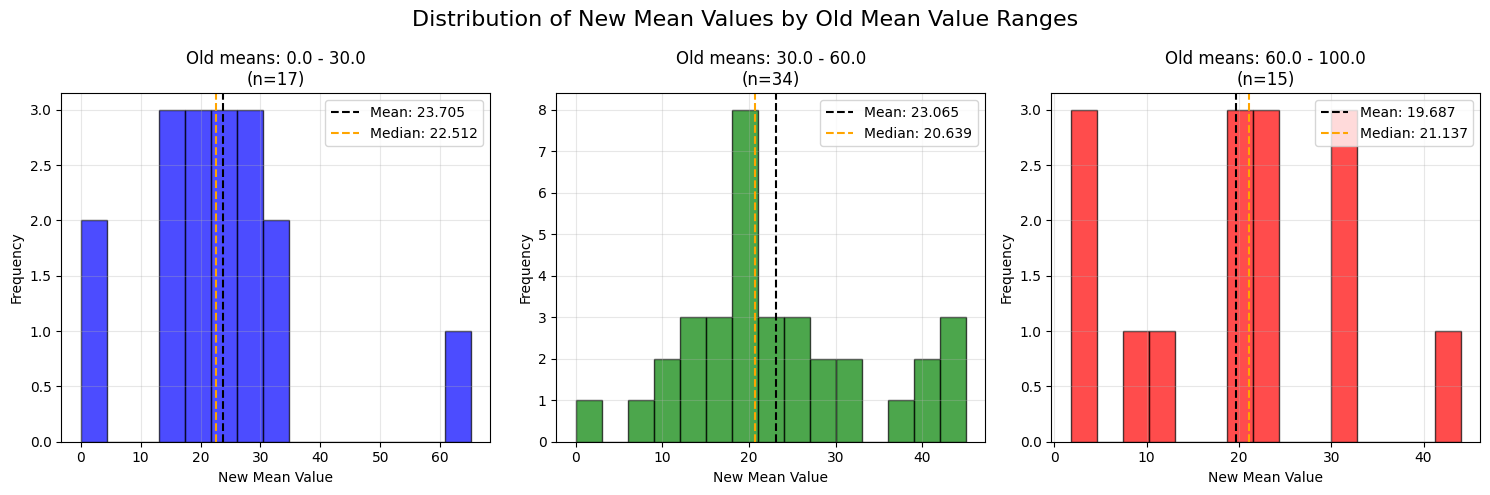

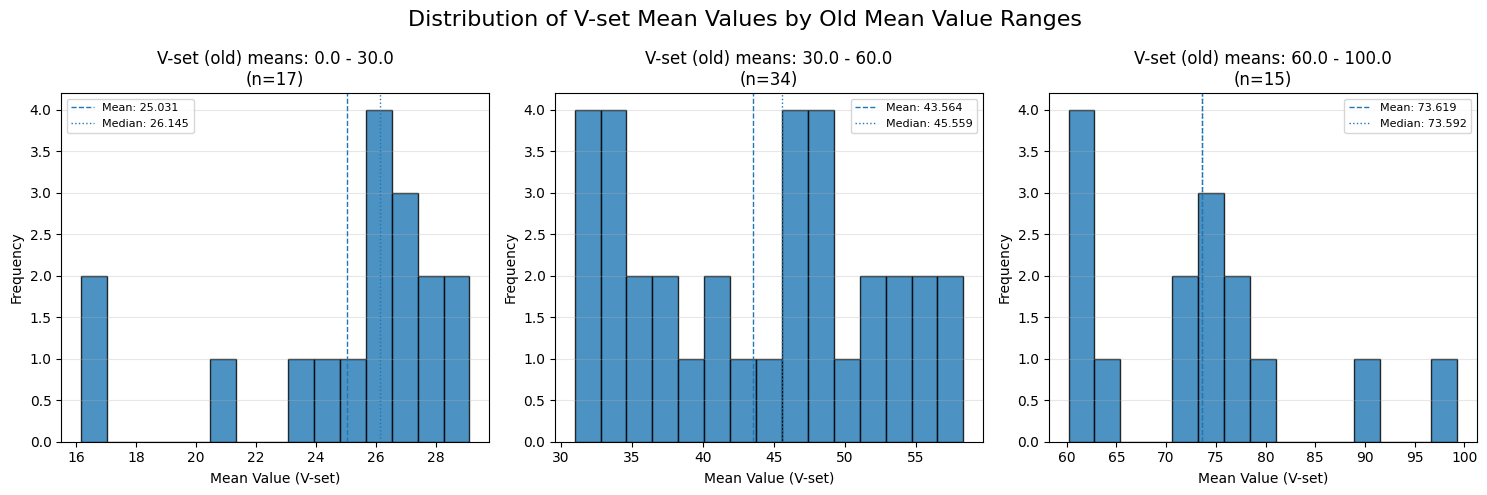

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_90281/3780539703.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_new_means, labels=all_labels)


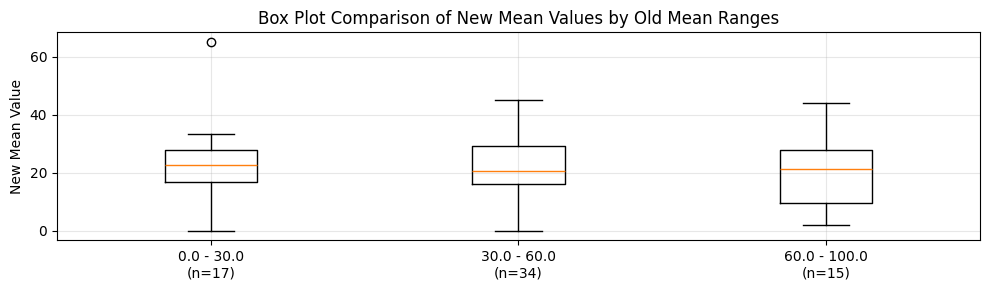

In [11]:

####*#**#*#*# Sanity check for functions below --- keep 


import numpy as np
import matplotlib.pyplot as plt

# Extract & sanitize inputs
old = np.asarray(v_mean, dtype=float)
new = np.asarray(v_new_mean, dtype=float)

# 1) Drop NaN/Inf in lockstep (keep only pairs where both are finite)
valid = np.isfinite(old) & np.isfinite(new)
old = old[valid]
new = new[valid]

# Define the ranges
ranges = [(0, 30), (30, 60), (60, 100)]
range_labels = ['0.0 - 30.0', '30.0 - 60.0', '60.0 - 100.0']
colors = ['blue', 'green', 'red']  # optional

# ----------------- Figure 1: T-set (new) distributions per OLD-mean range -----------------
plt.figure(figsize=(15, 5))
for i, (range_val, label, color) in enumerate(zip(ranges, range_labels, colors)):
    L, H = range_val
    mask = (old >= L) & (old < H) if i < len(ranges) - 1 else (old >= L) & (old <= H)

    new_r = new[mask]

    plt.subplot(1, 3, i + 1)
    if new_r.size > 0:
        plt.hist(new_r, bins=15, alpha=0.7, color=color, edgecolor='black')
        mean_v = float(np.mean(new_r))
        med_v  = float(np.median(new_r))
        plt.axvline(mean_v, color='black', linestyle='--', label=f'Mean: {mean_v:.3f}')
        plt.axvline(med_v,  color='orange', linestyle='--', label=f'Median: {med_v:.3f}')
        plt.title(f'Old means: {label}\n(n={new_r.size})')
        plt.xlabel('New Mean Value')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, f'No data in range\n{label}',
                 ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'Old means: {label}')

plt.suptitle('Distribution of New Mean Values by Old Mean Value Ranges', fontsize=16)
plt.tight_layout()
plt.show()

# ----------------- Figure 2: V-set (old) distributions per OLD-mean range -----------------
plt.figure(figsize=(15, 5))
for i, (range_val, label, color) in enumerate(zip(ranges, range_labels, colors)):
    L, H = range_val
    mask = (old >= L) & (old < H) if i < len(ranges) - 1 else (old >= L) & (old <= H)

    old_r = old[mask]

    plt.subplot(1, 3, i + 1)
    if old_r.size > 0:
        plt.hist(old_r, bins=15, alpha=0.8, edgecolor='black')
        mean_old = float(np.mean(old_r))
        med_old  = float(np.median(old_r))
        plt.axvline(mean_old, linestyle='--', linewidth=1, label=f'Mean: {mean_old:.3f}')
        plt.axvline(med_old,  linestyle=':',  linewidth=1, label=f'Median: {med_old:.3f}')
        plt.title(f'V-set (old) means: {label}\n(n={old_r.size})')
        plt.xlabel('Mean Value (V-set)')
        plt.ylabel('Frequency')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3, axis='y')
    else:
        plt.text(0.5, 0.5, f'No data in range\n{label}',
                 ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'V-set (old) means: {label}')

plt.suptitle('Distribution of V-set Mean Values by Old Mean Value Ranges', fontsize=16)
plt.tight_layout()
plt.show()

# ----------------- Figure 3: Box plot of NEW (T-set) by OLD-mean ranges -----------------
plt.figure(figsize=(10, 3))
all_new_means = []
all_labels = []

for i, (range_val, label) in enumerate(zip(ranges, range_labels)):
    L, H = range_val
    mask = (old >= L) & (old < H) if i < len(ranges) - 1 else (old >= L) & (old <= H)

    new_r = new[mask]
    if new_r.size > 0:
        all_new_means.append(new_r)
        all_labels.append(f'{label}\n(n={new_r.size})')

if all_new_means:
    plt.boxplot(all_new_means, labels=all_labels)
    plt.title('Box Plot Comparison of New Mean Values by Old Mean Ranges')
    plt.ylabel('New Mean Value')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No non-empty ranges for boxplot.")


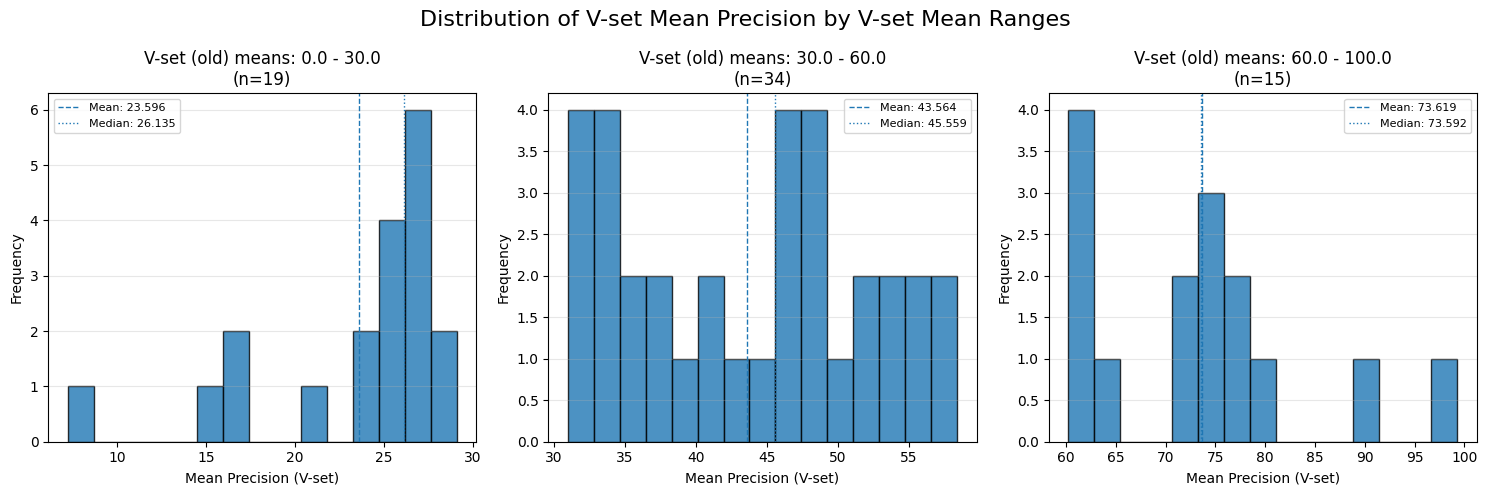

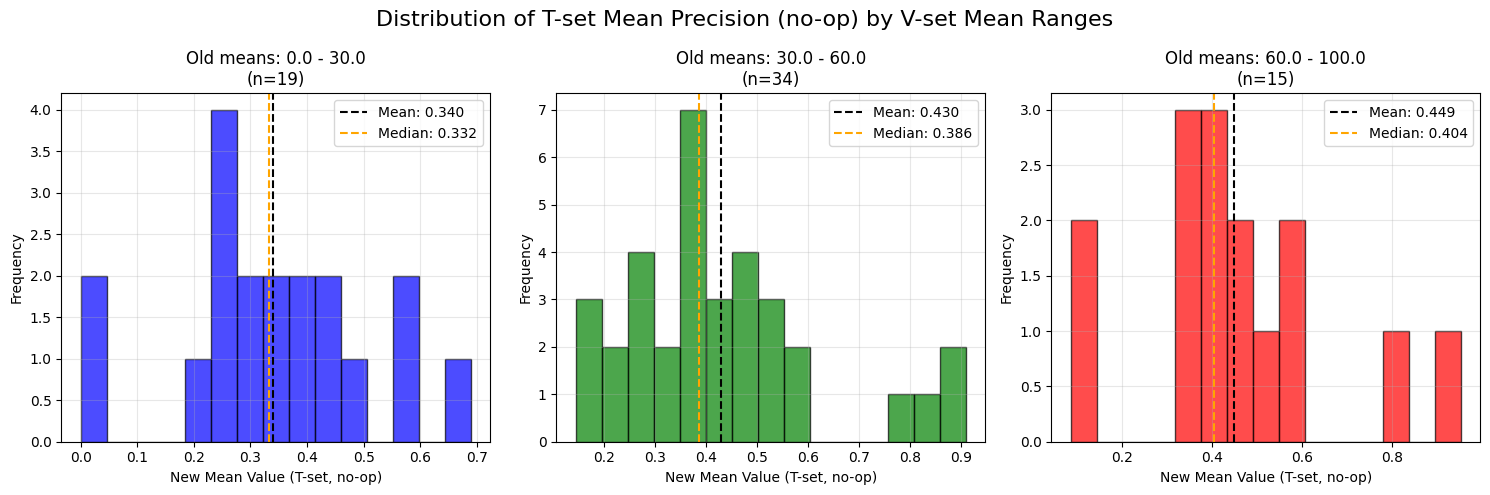

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_90281/1843216672.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_new_means, labels=all_labels)


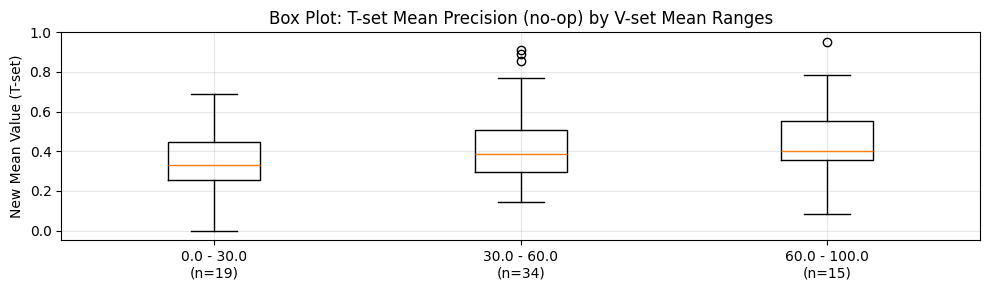

Statistics by Old (V-set) Mean Range:

Range: 0.0 - 30.0
  Count: 19
  T-set mean (no-op) - Mean:   0.3400
  T-set mean (no-op) - Median: 0.3320
  T-set mean (no-op) - Std:    0.1677
  T-set mean (no-op) - Min:    0.0000
  T-set mean (no-op) - Max:    0.6889
  V-set mean - Mean:           23.5955

Range: 30.0 - 60.0
  Count: 34
  T-set mean (no-op) - Mean:   0.4305
  T-set mean (no-op) - Median: 0.3865
  T-set mean (no-op) - Std:    0.1918
  T-set mean (no-op) - Min:    0.1455
  T-set mean (no-op) - Max:    0.9085
  V-set mean - Mean:           43.5639

Range: 60.0 - 100.0
  Count: 15
  T-set mean (no-op) - Mean:   0.4486
  T-set mean (no-op) - Median: 0.4038
  T-set mean (no-op) - Std:    0.2133
  T-set mean (no-op) - Min:    0.0859
  T-set mean (no-op) - Max:    0.9524
  V-set mean - Mean:           73.6186


In [12]:

import numpy as np
import matplotlib.pyplot as plt

# ---------- 0) Get metrics ONLY via your functions ----------
# Select *all* models on V-set (no filtering)
selected_models_all = select_models_by_criteria(
    results_data=results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(0, 100),
    min_seeds_per_model=1,
    max_models_to_return=len(results_dist_disc),  # include all; prevents sampling cap
    max_zero_precision_seeds=None,
    min_ratio_difference=None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs=None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,
    random_seed=None,
)

# tset_models_keep = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
#                                       selected_models=selected_models_all,
#                                       brackets=((0.5, 0.7), (0.7, 1.0)))

# Recompute the same models on T-set with a NO-OP policy (no FP rewriting)
tset_models_keep = recompute_metrics_ignoring_pos_fp(
    selected_models_output=selected_models_all,
    results_data=results_dist_disc_Tset_same_seeds_organized,
    targets=("pos_high"),           # target nothing
    fp_treatment="flip_to_tp",    # leave FPs as-is (no-op)
)

# ---------- 1) Build aligned vectors (OLD = V-set means, NEW = T-set means) ----------
old_map = {m["combo_index"]: m.get("mean_precision", np.nan) for m in selected_models_all}
new_map = {m["combo_index"]: m.get("mean_precision", np.nan) for m in tset_models_keep}

# Keep consistent V-set ordering and only models present in both
combo_order = [m["combo_index"] for m in selected_models_all if m["combo_index"] in new_map]

v_mean     = np.array([old_map[c] for c in combo_order], dtype=float)  # OLD = V-set (from selection fn)
v_new_mean = np.array([new_map[c] for c in combo_order], dtype=float)  # NEW = T-set (from recompute fn)

# Drop NaN/Inf in lockstep (keep only pairs where both are finite)
valid = np.isfinite(v_mean) & np.isfinite(v_new_mean)
old = v_mean[valid]
new = v_new_mean[valid]

# ---------- 2) Define OLD-mean ranges (bin by OLD) ----------
ranges = [(0, 30), (30, 60), (60, 100)]
range_labels = ['0.0 - 30.0', '30.0 - 60.0', '60.0 - 100.0']
colors = ['blue', 'green', 'red']

def range_mask(arr, i, L, H):
    return ((arr >= L) & (arr < H)) if i < len(ranges) - 1 else ((arr >= L) & (arr <= H))

# ---------- 3) Figure A: V-set (old) distributions per OLD-mean range ----------
plt.figure(figsize=(15, 5))
for i, ((L, H), label, color) in enumerate(zip(ranges, range_labels, colors)):
    mask = range_mask(old, i, L, H)
    old_r = old[mask]

    ax = plt.subplot(1, 3, i + 1)
    if old_r.size > 0:
        plt.hist(old_r, bins=15, alpha=0.8, edgecolor='black')
        mean_old = float(np.mean(old_r))
        med_old  = float(np.median(old_r))
        plt.axvline(mean_old, linestyle='--', linewidth=1, label=f'Mean: {mean_old:.3f}')
        plt.axvline(med_old,  linestyle=':',  linewidth=1, label=f'Median: {med_old:.3f}')
        plt.title(f'V-set (old) means: {label}\n(n={old_r.size})')
        plt.xlabel('Mean Precision (V-set)'); plt.ylabel('Frequency')
        plt.legend(fontsize=8); plt.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, f'No data in range\n{label}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'V-set (old) means: {label}')
plt.suptitle('Distribution of V-set Mean Precision by V-set Mean Ranges', fontsize=16)
plt.tight_layout(); plt.show()

# ---------- 4) Figure B: T-set (new) distributions per OLD-mean range ----------
plt.figure(figsize=(15, 5))
for i, ((L, H), label, color) in enumerate(zip(ranges, range_labels, colors)):
    mask = range_mask(old, i, L, H)  # binning by OLD means
    new_r = new[mask]

    ax = plt.subplot(1, 3, i + 1)
    if new_r.size > 0:
        plt.hist(new_r, bins=15, alpha=0.7, color=color, edgecolor='black')
        mean_new = float(np.mean(new_r))
        med_new  = float(np.median(new_r))
        plt.axvline(mean_new, color='black', linestyle='--', label=f'Mean: {mean_new:.3f}')
        plt.axvline(med_new,  color='orange', linestyle='--', label=f'Median: {med_new:.3f}')
        plt.title(f'Old means: {label}\n(n={new_r.size})')
        plt.xlabel('New Mean Value (T-set, no-op)'); plt.ylabel('Frequency')
        plt.legend(); plt.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No data in range\n{label}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Old means: {label}')
plt.suptitle('Distribution of T-set Mean Precision (no-op) by V-set Mean Ranges', fontsize=16)
plt.tight_layout(); plt.show()

# ---------- 5) Figure C: Box plot of NEW (T-set) by OLD-mean ranges ----------
plt.figure(figsize=(10, 3))
all_new_means, all_labels = [], []
for i, ((L, H), label) in enumerate(zip(ranges, range_labels)):
    mask = range_mask(old, i, L, H)
    new_r = new[mask]
    if new_r.size > 0:
        all_new_means.append(new_r)
        all_labels.append(f'{label}\n(n={new_r.size})')
if all_new_means:
    plt.boxplot(all_new_means, labels=all_labels)
    plt.title('Box Plot: T-set Mean Precision (no-op) by V-set Mean Ranges')
    plt.ylabel('New Mean Value (T-set)')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("No non-empty ranges for boxplot.")

# ---------- 6) Stats printout ----------
print("Statistics by Old (V-set) Mean Range:")
print("=" * 50)
for i, ((L, H), label) in enumerate(zip(ranges, range_labels)):
    mask = range_mask(old, i, L, H)
    new_r = new[mask]; old_r = old[mask]
    if new_r.size > 0:
        print(f"\nRange: {label}")
        print(f"  Count: {new_r.size}")
        print(f"  T-set mean (no-op) - Mean:   {np.mean(new_r):.4f}")
        print(f"  T-set mean (no-op) - Median: {np.median(new_r):.4f}")
        print(f"  T-set mean (no-op) - Std:    {np.std(new_r, ddof=0):.4f}")
        print(f"  T-set mean (no-op) - Min:    {np.min(new_r):.4f}")
        print(f"  T-set mean (no-op) - Max:    {np.max(new_r):.4f}")
        print(f"  V-set mean - Mean:           {np.mean(old_r):.4f}")
    else:
        print(f"\nRange: {label} - No data")


In [13]:
selected_models = select_models_by_criteria(
    results_data=results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(0, 100),
    min_seeds_per_model=1,
    max_models_to_return=len(results_dist_disc),  # include all; prevents sampling cap
    max_zero_precision_seeds=None,
    min_ratio_difference=0.4,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs=None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,
    random_seed=None,
)



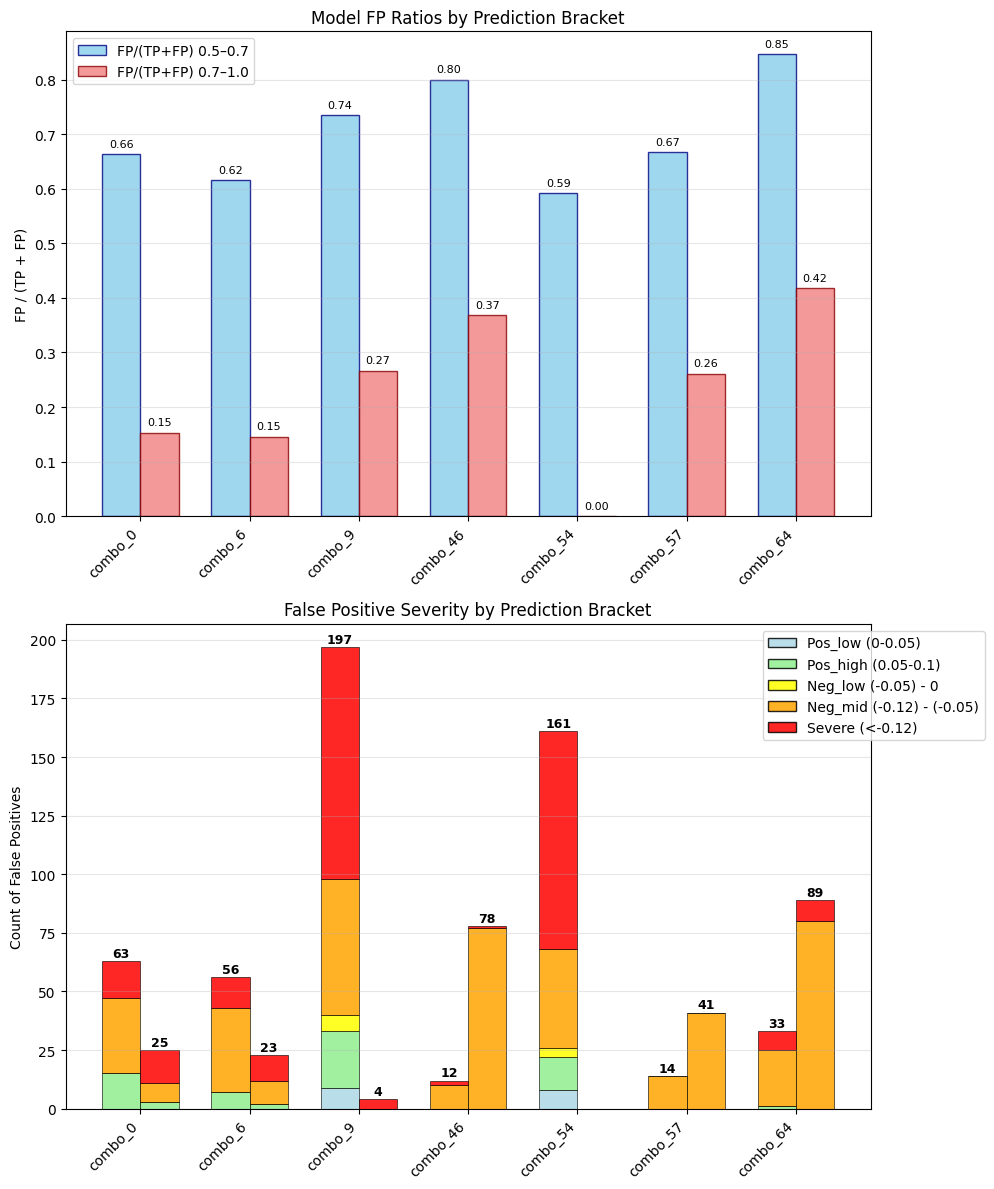

In [14]:
import numpy as np
import matplotlib.pyplot as plt

SEVERITY_CATS = [
    "Pos_low (0-0.05)",
    "Pos_high (0.05-0.1)",
    "Neg_low (-0.05) - 0",
    "Neg_mid (-0.12) - (-0.05)",
    "Severe (<-0.12)",
]
SEVERITY_COLORS = {
    "Pos_low (0-0.05)": 'lightblue',
    "Pos_high (0.05-0.1)": 'lightgreen',
    "Neg_low (-0.05) - 0": 'yellow',
    "Neg_mid (-0.12) - (-0.05)": 'orange',
    "Severe (<-0.12)": 'red',
    "Other": 'gray',
}

if not selected_models:
    print("No models to plot.")
else:
    labels = [f"combo_{m['combo_index']}" for m in selected_models]
    x = np.arange(len(labels))
    width = 0.35

    # --- Plot 1: FP Ratios (from fp_tp_ratios in selected_models) ---
    r_05_07 = [m.get("fp_tp_ratios", {}).get("0.5-0.7", np.nan) for m in selected_models]
    r_07_10 = [m.get("fp_tp_ratios", {}).get("0.7-1.0", np.nan) for m in selected_models]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, len(labels)*0.8), 12))

    b1 = ax1.bar(x - width/2, r_05_07, width, label='FP/(TP+FP) 0.5–0.7',
                 alpha=0.8, color='skyblue', edgecolor='navy')
    b2 = ax1.bar(x + width/2, r_07_10, width, label='FP/(TP+FP) 0.7–1.0',
                 alpha=0.8, color='lightcoral', edgecolor='darkred')
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.set_ylabel('FP / (TP + FP)'); ax1.set_title('Model FP Ratios by Prediction Bracket')
    ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

    for i, (v1, v2) in enumerate(zip(r_05_07, r_07_10)):
        if not np.isnan(v1): ax1.text(i - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', va='bottom', fontsize=8)
        if not np.isnan(v2): ax1.text(i + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', va='bottom', fontsize=8)

    # --- Plot 2: Severity Breakdown (read from fp_severity_by_bracket) ---
    # Build arrays directly from each model's fp_severity_by_bracket
    def get_counts(model, bracket_key, cat):
        d = model.get("fp_severity_by_bracket", {}).get(bracket_key, {})
        return int(d.get(cat, 0))

    low_data  = {cat: [get_counts(m, "0.5-0.7", cat) for m in selected_models] for cat in SEVERITY_CATS}
    high_data = {cat: [get_counts(m, "0.7-1.0", cat) for m in selected_models] for cat in SEVERITY_CATS}

    bottom_low  = np.zeros(len(labels))
    bottom_high = np.zeros(len(labels))
    legend_handles = []

    for cat in SEVERITY_CATS:
        color = SEVERITY_COLORS.get(cat, 'gray')
        ax2.bar(x - width/2, low_data[cat],  width, bottom=bottom_low,  color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        ax2.bar(x + width/2, high_data[cat], width, bottom=bottom_high, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        bottom_low  += np.array(low_data[cat])
        bottom_high += np.array(high_data[cat])
        legend_handles.append(plt.Rectangle((0,0), 1, 1, fc=color, alpha=0.85, label=cat, edgecolor='black'))

    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.set_ylabel('Count of False Positives')
    ax2.set_title('False Positive Severity by Prediction Bracket')
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3, axis='y')

    # Totals above bars
    total_low  = bottom_low
    total_high = bottom_high
    for i in range(len(labels)):
        if total_low[i]  > 0: ax2.text(i - width/2, total_low[i]  + 0.5, int(total_low[i]),  ha='center', va='bottom', fontsize=9, fontweight='bold')
        if total_high[i] > 0: ax2.text(i + width/2, total_high[i] + 0.5, int(total_high[i]), ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # # --- Summary printout using the same data (no raw re-walk) ---
    # print("\n" + "="*60)
    # print("SEVERE CASE PROPORTIONS BY BRACKET")
    # print("="*60)
    # for i, label in enumerate(labels):
    #     low_counts  = [low_data[cat][i]  for cat in SEVERITY_CATS]
    #     high_counts = [high_data[cat][i] for cat in SEVERITY_CATS]
    #     total_low   = sum(low_counts)
    #     total_high  = sum(high_counts)
    #     severe_low  = low_data["Severe (<-0.12)"][i]
    #     severe_high = high_data["Severe (<-0.12)"][i]

    #     prop_low  = (severe_low  / total_low  * 100) if total_low  > 0 else 0
    #     prop_high = (severe_high / total_high * 100) if total_high > 0 else 0

    #     print(f"{label}:")
    #     print(f"  Low bracket (0.5-0.7): {prop_low:.1f}% severe ({severe_low}/{total_low})")
    #     print(f"  High bracket (0.7-1.0): {prop_high:.1f}% severe ({severe_high}/{total_high})")
    #     print("-" * 40)


In [15]:
# results_dist_disc[0]["per_seed_all_results"][0]["result_entry"].keys()

# dict_keys(['combo_number', 'parameters', 'cv_sets', 'all_preds', 'all_actuals', 'raw_actuals', 'Y_vals_dates_LIST'])

Models Selected control: 70
Total seeds selected control: 3962
Models Selected HIGH: 8
Total seeds selected HIGH: 414
Models Selected LOW: 15
Total seeds selected LOW: 1001


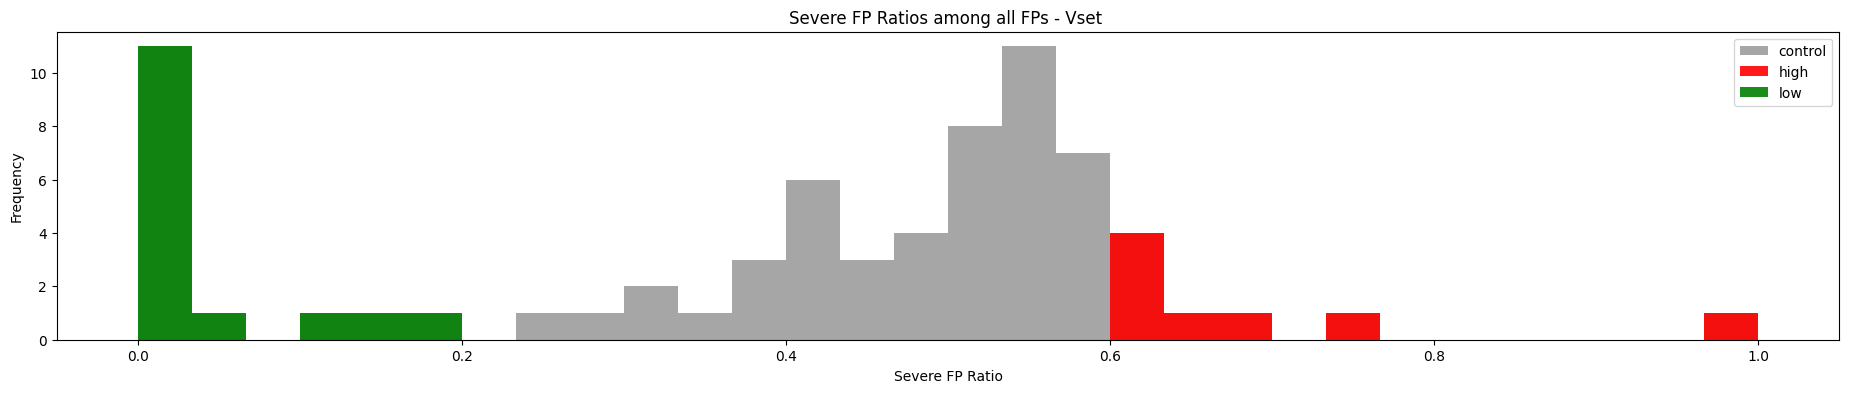

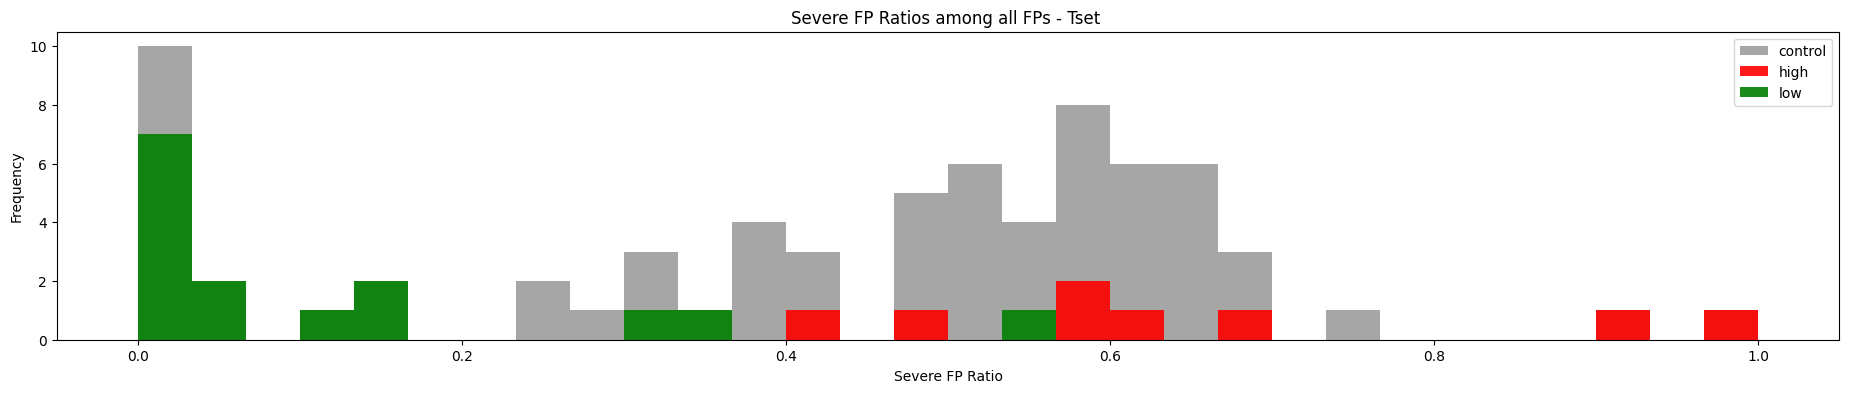

In [16]:
import random
####                                                                                TESTING max_FP_severe_ratio_FPs
# Run the model selection function with the new parameters
selected_models_control = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

selected_models_test_LOW_ratio___fp_severe_ratio_fps = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference=None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= .2,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)


selected_models_test_HIGH_ratio___fp_severe_ratio_fps = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs= .6,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

selected_models_control_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_control,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_test_LOW_ratio___fp_severe_ratio_fps_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_test_LOW_ratio___fp_severe_ratio_fps,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_test_HIGH_ratio___fp_severe_ratio_fps_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_test_HIGH_ratio___fp_severe_ratio_fps,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))




# Print summary of selected models
print(f"Models Selected control: {len(selected_models_control)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_control)
print(f"Total seeds selected control: {total_seeds}")

print(f"Models Selected HIGH: {len(selected_models_test_HIGH_ratio___fp_severe_ratio_fps)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_test_HIGH_ratio___fp_severe_ratio_fps)
print(f"Total seeds selected HIGH: {total_seeds}")

print(f"Models Selected LOW: {len(selected_models_test_LOW_ratio___fp_severe_ratio_fps)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_test_LOW_ratio___fp_severe_ratio_fps)
print(f"Total seeds selected LOW: {total_seeds}")


#his tof all severe FPs among all MODELS

list_ALL_fp_severe_ratio_fps_control = []
for i in selected_models_control:
    list_ALL_fp_severe_ratio_fps_control.append(i["fp_severe_ratio_fps"])

list_ALL_fp_severe_ratio_fps_low = []
for i in selected_models_test_LOW_ratio___fp_severe_ratio_fps:
    list_ALL_fp_severe_ratio_fps_low.append(i["fp_severe_ratio_fps"])

list_ALL_fp_severe_ratio_fps_high = []
for i in selected_models_test_HIGH_ratio___fp_severe_ratio_fps: 
    list_ALL_fp_severe_ratio_fps_high.append(i["fp_severe_ratio_fps"])

######################
list_ALL_fp_severe_ratio_fps_control_TEST = []
for i in selected_models_control_TEST:
    list_ALL_fp_severe_ratio_fps_control_TEST.append(i["fp_severe_ratio_fps"])

list_ALL_fp_severe_ratio_fps_low_TEST = []
for i in selected_models_test_LOW_ratio___fp_severe_ratio_fps_TEST:
    list_ALL_fp_severe_ratio_fps_low_TEST.append(i["fp_severe_ratio_fps"])

list_ALL_fp_severe_ratio_fps_high_TEST = []
for i in selected_models_test_HIGH_ratio___fp_severe_ratio_fps_TEST:
    list_ALL_fp_severe_ratio_fps_high_TEST.append(i["fp_severe_ratio_fps"])


all_vals = list_ALL_fp_severe_ratio_fps_control + list_ALL_fp_severe_ratio_fps_low + list_ALL_fp_severe_ratio_fps_high
Bins = np.linspace(min(all_vals), max(all_vals), 31)  # 30 bins, same edges for all

plt.figure(figsize = (23 , 4))
plt.hist(list_ALL_fp_severe_ratio_fps_control , bins=Bins , alpha = 0.7 , label = "control" , color = "grey")
plt.hist(list_ALL_fp_severe_ratio_fps_high , bins = Bins , alpha = 0.9 , label = "high" , color = "red")
plt.hist(list_ALL_fp_severe_ratio_fps_low , bins = Bins , alpha = 0.9 , label = "low" , color = "green")
plt.title("Severe FP Ratios among all FPs - Vset ")
plt.xlabel("Severe FP Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.show()


all_vals = list_ALL_fp_severe_ratio_fps_control_TEST + list_ALL_fp_severe_ratio_fps_low_TEST + list_ALL_fp_severe_ratio_fps_high_TEST
Bins = np.linspace(min(all_vals), max(all_vals), 31)  # 30 bins, same edges for all

plt.figure(figsize = (23 , 4))
plt.hist(list_ALL_fp_severe_ratio_fps_control_TEST , bins=Bins , alpha = 0.7 , label = "control" , color = "grey")
plt.hist(list_ALL_fp_severe_ratio_fps_high_TEST , bins = Bins , alpha = 0.9 , label = "high" , color = "red")
plt.hist(list_ALL_fp_severe_ratio_fps_low_TEST , bins = Bins , alpha = 0.9 , label = "low" , color = "green")
plt.title("Severe FP Ratios among all FPs - Tset ")
plt.xlabel("Severe FP Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.show()





Models Selected control: 70
Total seeds selected control: 3962
Models Selected POS: 51
Total seeds selected POS: 3060
Models Selected NEG: 10
Total seeds selected NEG: 464
Models Selected LOW: 70
Total seeds selected Adjusted Control: 3962


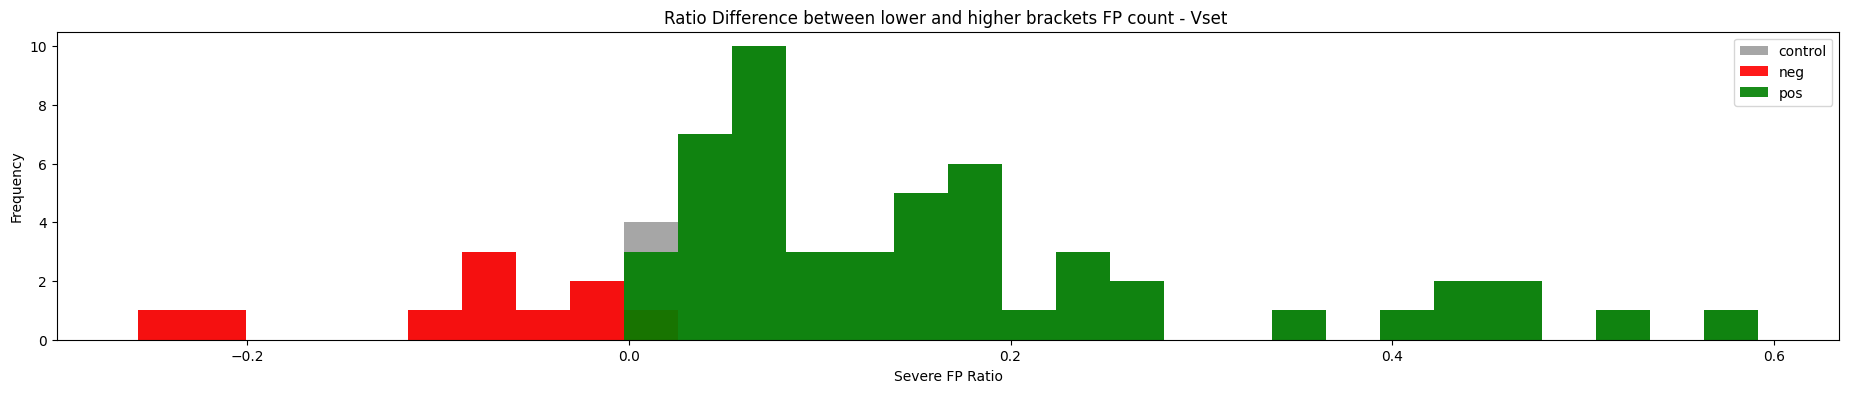

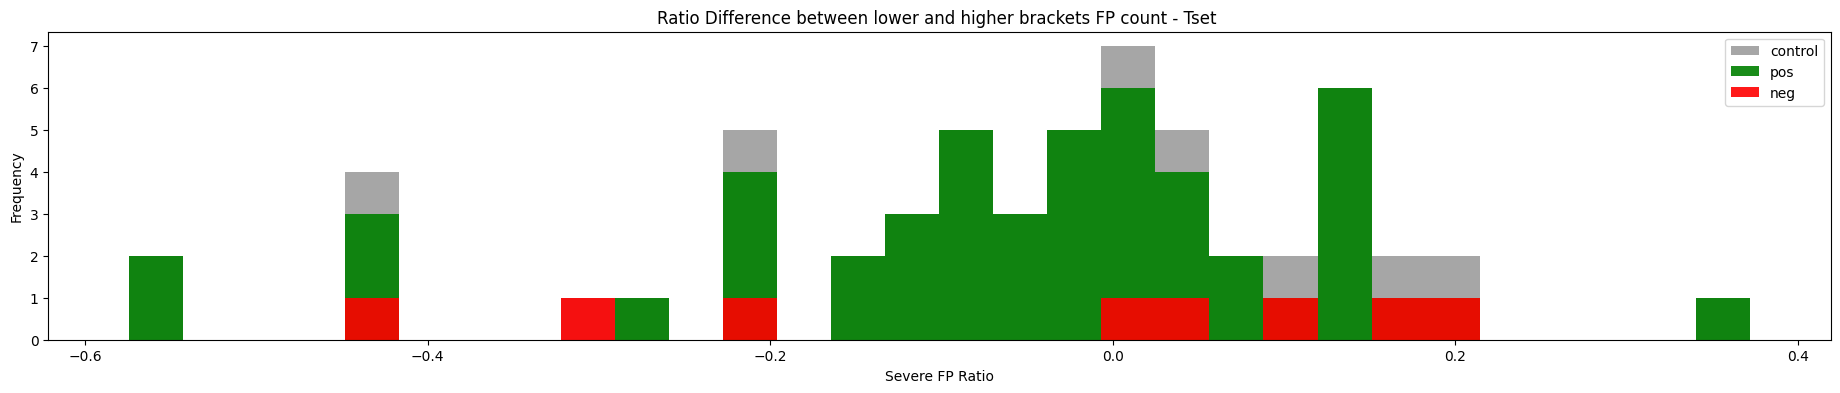

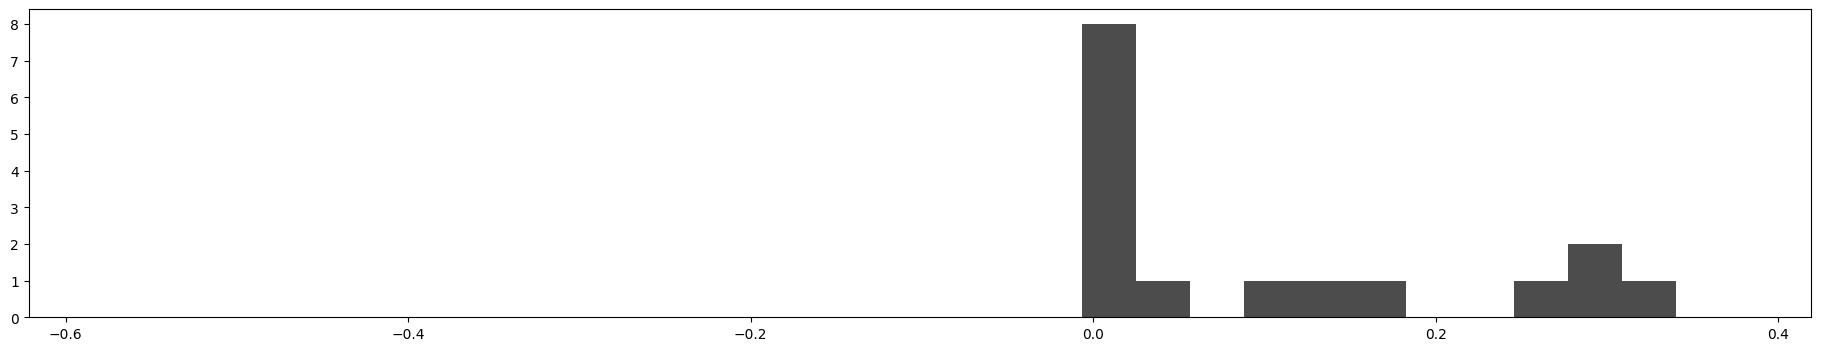

In [18]:
####                                                                                TESTING min_ratio_difference between higher and lower brackets FP count 

## still to be tested: remove the pos high adn see fi the dist change is less severe 



# Run the model selection function with the new parameters
selected_models_control = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

selected_models_test_POS_ratio = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference=0,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)


selected_models_test_NEG_ratio = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference= 0,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs= None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

selected_models_control_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_control,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_test_POS_ratio_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_test_POS_ratio,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_test_NEG_ratio_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_test_NEG_ratio,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_control_TEST_ADJUSTED_FPs = recompute_metrics_ignoring_pos_fp(
    selected_models_output = selected_models_control_TEST,
    results_data = results_dist_disc_Tset_same_seeds_organized,
    targets=("pos_high"),
    fp_treatment="ignore",
)



# Print summary of selected models
print(f"Models Selected control: {len(selected_models_control)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_control)
print(f"Total seeds selected control: {total_seeds}")

print(f"Models Selected POS: {len(selected_models_test_POS_ratio)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_test_POS_ratio)
print(f"Total seeds selected POS: {total_seeds}")

print(f"Models Selected NEG: {len(selected_models_test_NEG_ratio)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_test_NEG_ratio)
print(f"Total seeds selected NEG: {total_seeds}")

print(f"Models Selected LOW: {len(selected_models_control_TEST_ADJUSTED_FPs)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models_control_TEST_ADJUSTED_FPs)
print(f"Total seeds selected Adjusted Control: {total_seeds}")


#his tof all severe FPs among all MODELS

list_ALL_control = []
for i in selected_models_control:
    list_ALL_control.append(i["ratio_difference"])

list_ALL_control = [i for i in list_ALL_control if i is not None]

list_ALL_neg = []
for i in selected_models_test_NEG_ratio:
    list_ALL_neg.append(i["ratio_difference"])

list_ALL_pos = []
for i in selected_models_test_POS_ratio:
    list_ALL_pos.append(i["ratio_difference"])

######################

list_ALL_control_TEST = []
for i in selected_models_control_TEST:
    list_ALL_control_TEST.append(i["ratio_difference"])

list_ALL_control_TEST = [i for i in list_ALL_control_TEST if i is not None]

list_ALL_fp_severe_ratio_fps_control_TEST_ADJUSTED_FPs = []
for i in selected_models_control_TEST_ADJUSTED_FPs:
    list_ALL_fp_severe_ratio_fps_control_TEST_ADJUSTED_FPs.append(i["fp_severe_ratio_fps"])



list_ALL_neg_TEST = []
for i in selected_models_test_NEG_ratio_TEST:
    list_ALL_neg_TEST.append(i["ratio_difference"])

list_ALL_neg_TEST = [i for i in list_ALL_neg_TEST if i is not None]

list_ALL_pos_TEST = []
for i in selected_models_test_POS_ratio_TEST:
    list_ALL_pos_TEST.append(i["ratio_difference"])

list_ALL_pos_TEST = [i for i in list_ALL_pos_TEST if i is not None]


all_vals = list_ALL_control + list_ALL_neg + list_ALL_pos
Bins = np.linspace(min(all_vals), max(all_vals), 31)  # 30 bins, same edges for all



plt.figure(figsize = (23 , 4))
plt.hist(list_ALL_control , bins=Bins , alpha = 0.7 , label = "control" , color = "grey")
plt.hist(list_ALL_neg , bins = Bins , alpha = 0.9 , label = "neg" , color = "red")
plt.hist(list_ALL_pos , bins = Bins , alpha = 0.9 , label = "pos" , color = "green")
plt.title("Ratio Difference between lower and higher brackets FP count - Vset ")
plt.xlabel("Severe FP Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.show()


all_vals = list_ALL_control_TEST + list_ALL_neg_TEST + list_ALL_pos_TEST
Bins = np.linspace(min(all_vals), max(all_vals), 31)  # 30 bins, same edges for all


plt.figure(figsize = (23 , 4))
plt.hist(list_ALL_control_TEST , bins= Bins , alpha = 0.7 , label = "control" , color = "grey")
# plt.hist(list_ALL_fp_severe_ratio_fps_control_TEST_ADJUSTED_FPs , bins=Bins , alpha = 0.7 , label = "control - adjusted FPs" , color = "black" )
plt.hist(list_ALL_pos_TEST , bins = Bins , alpha = 0.9 , label = "pos" , color = "green")
plt.hist(list_ALL_neg_TEST , bins = Bins , alpha = 0.9 , label = "neg" , color = "red")
plt.title("Ratio Difference between lower and higher brackets FP count - Tset ")
plt.xlabel("Severe FP Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.show()


plt.figure(figsize = (23 , 4))
plt.hist(list_ALL_fp_severe_ratio_fps_control_TEST_ADJUSTED_FPs , bins=Bins , alpha = 0.7 , label = "control - adjusted FPs" , color = "black" )
plt.show()






In [17]:


# Run the model selection function with the new parameters
selected_models = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(75, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=0,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

# Print summary of selected models
print(f"Models Selected control: {len(selected_models)}")
total_seeds = sum(len(model["selected_seeds"]) for model in selected_models)
print(f"Total seeds selected control: {total_seeds}")


Models Selected control: 6
Total seeds selected control: 400


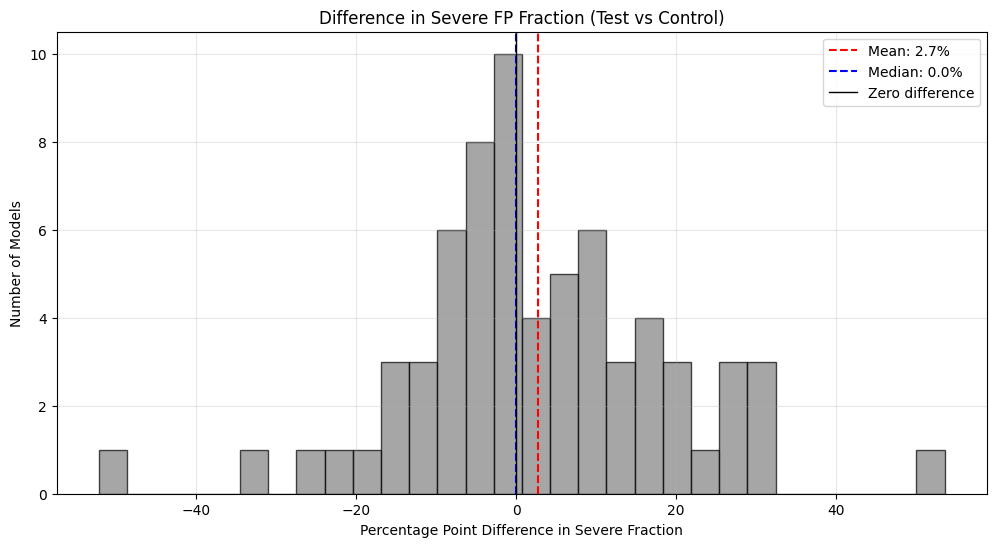

Models analyzed: 68
Mean difference: 2.72 percentage points
Median difference: 0.00 percentage points
Std deviation: 16.65 percentage points


: 

: 

: 

: 

In [ ]:
######                                                                        Testing the difference in severe FP fraction between test and control models 

## use frations since the number of preds in the T set and the V set are different



selected_models_control = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference=None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs=None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,
    random_seed=42,
    max_models_to_return=70
)

selected_models_control_TEST = recompute_selected_models_on_Tset(
    results_dist_disc_Tset_same_seeds_organized,
    selected_models_control,
    brackets=((0.5, 0.7), (0.7, 1.0))
)

# Create mapping for model matching
test_models_map = {model["combo_index"]: model for model in selected_models_control_TEST}

# Calculate severe fraction differences
severe_fraction_differences = []
for control_model in selected_models_control:
    combo_idx = control_model["combo_index"]
    test_model = test_models_map.get(combo_idx)
    
    if test_model and "fp_severity_by_bracket" in control_model and "fp_severity_by_bracket" in test_model:
        # Calculate total FPs and severe FPs for control model
        control_total_fp = sum(bracket_counts["FP"] for bracket_counts in control_model["bracket_counts"].values())
        control_severe_fp = sum(bracket_data.get("Severe (<-0.12)", 0) 
                              for bracket_data in control_model["fp_severity_by_bracket"].values())
        
        # Calculate total FPs and severe FPs for test model
        test_total_fp = sum(bracket_counts["FP"] for bracket_counts in test_model["bracket_counts"].values())
        test_severe_fp = sum(bracket_data.get("Severe (<-0.12)", 0) 
                           for bracket_data in test_model["fp_severity_by_bracket"].values())
        
        # Calculate severe fractions
        if control_total_fp > 0 and test_total_fp > 0:
            control_severe_frac = control_severe_fp / control_total_fp
            test_severe_frac = test_severe_fp / test_total_fp
            
            # Calculate percentage difference in severe fraction
            severe_frac_diff = (test_severe_frac - control_severe_frac) * 100  # Convert to percentage
            severe_fraction_differences.append(severe_frac_diff)

# Plot results
if severe_fraction_differences:
    plt.figure(figsize=(12, 6))
    plt.hist(severe_fraction_differences, bins=30, alpha=0.7, color='grey', edgecolor='black')
    plt.axvline(np.mean(severe_fraction_differences), color='red', linestyle='--', 
                label=f'Mean: {np.mean(severe_fraction_differences):.1f}%')
    plt.axvline(np.median(severe_fraction_differences), color='blue', linestyle='--', 
                label=f'Median: {np.median(severe_fraction_differences):.1f}%')
    plt.axvline(0, color='black', linestyle='-', linewidth=1, label='Zero difference')
    plt.title("Difference in Severe FP Fraction (Test vs Control)")
    plt.xlabel("Percentage Point Difference in Severe Fraction")
    plt.ylabel("Number of Models")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Print summary statistics
    print(f"Models analyzed: {len(severe_fraction_differences)}")
    print(f"Mean difference: {np.mean(severe_fraction_differences):.2f} percentage points")
    print(f"Median difference: {np.median(severe_fraction_differences):.2f} percentage points")
    print(f"Std deviation: {np.std(severe_fraction_differences):.2f} percentage points")

In [19]:
#####                                  SEED BASED ANALYSIS: max_seed_severe_FPs_high_bracket and min_seed_TPs_high_bracket


# Run the model selection function with the new parameters
selected_models_control = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

selected_models_test_highTP = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference=None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=1,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=.15,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=0,
    min_seed_TPs_high_bracket=1,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)


selected_models_control_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_control,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))

selected_models_test_highTP_TEST = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
                                      selected_models_test_highTP,
                                      brackets=((0.5, 0.7), (0.7, 1.0)))




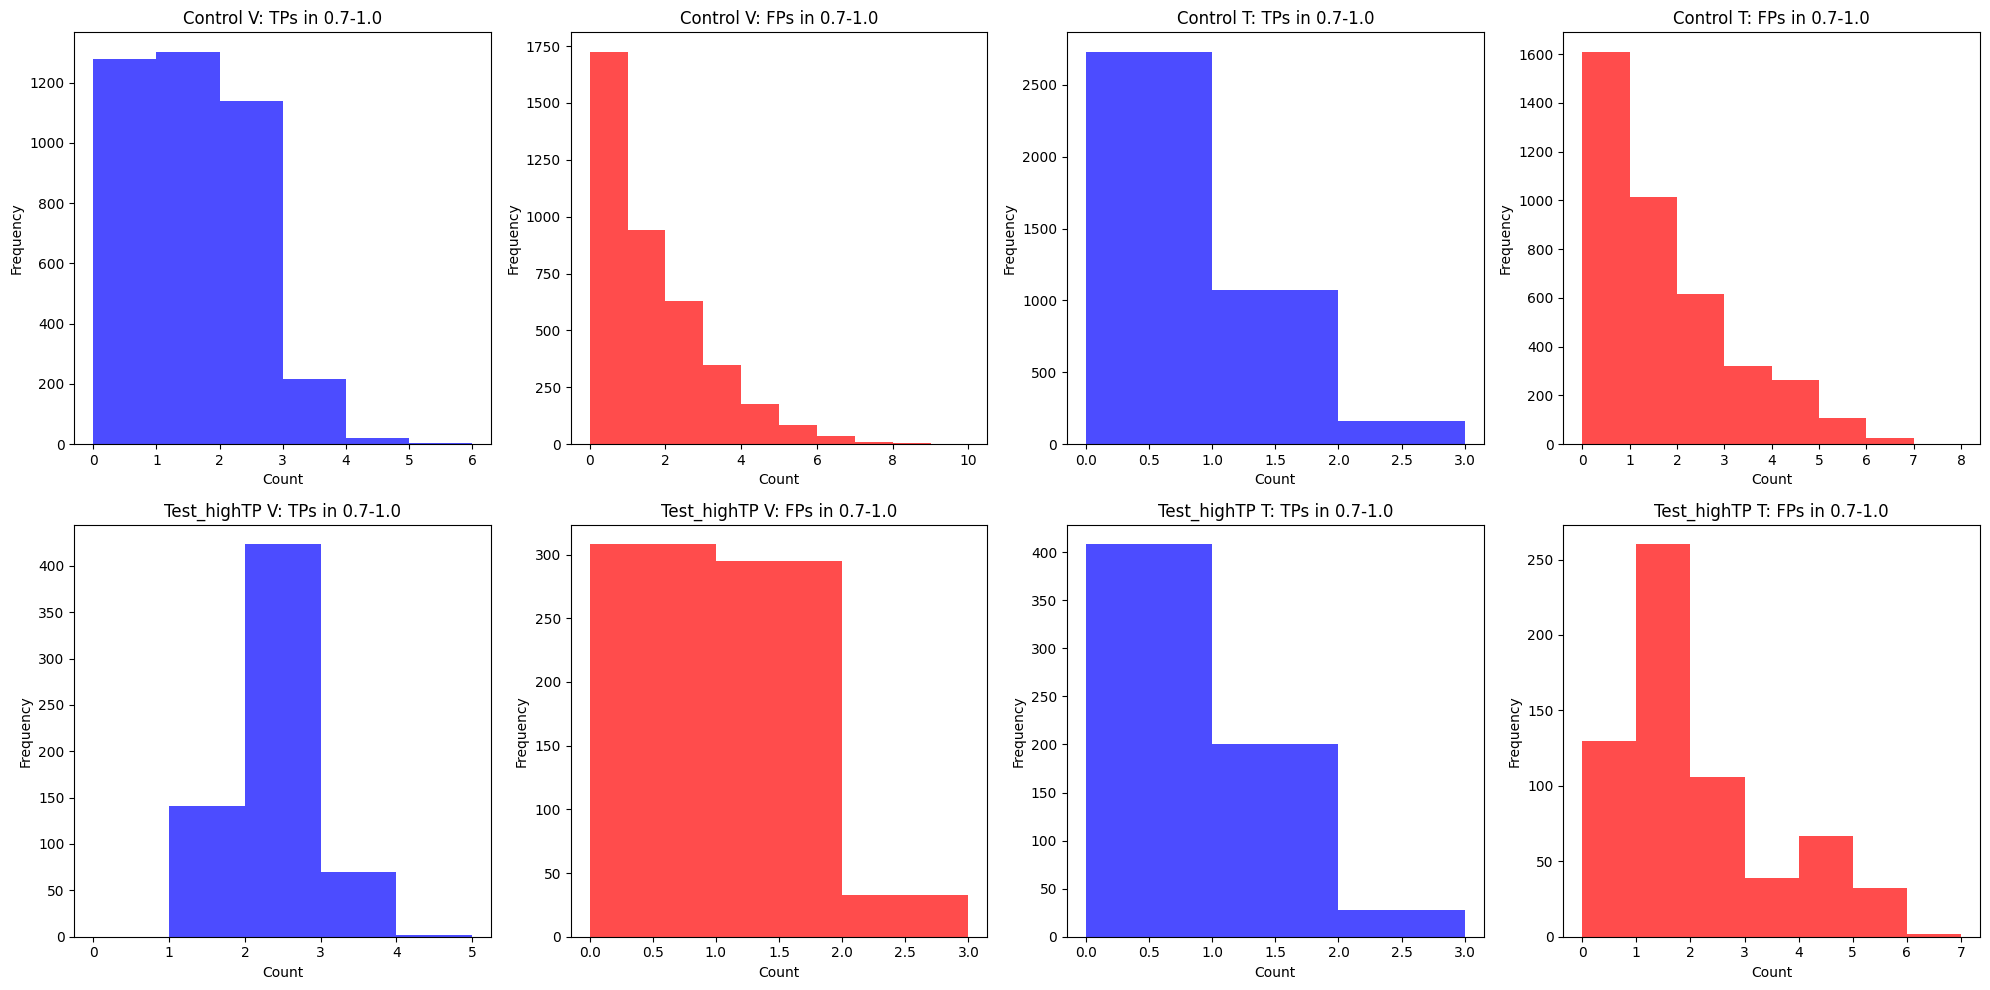

Control V seeds: 3962
Control T seeds: 3962
Test_highTP V seeds: 636
Test_highTP T seeds: 636


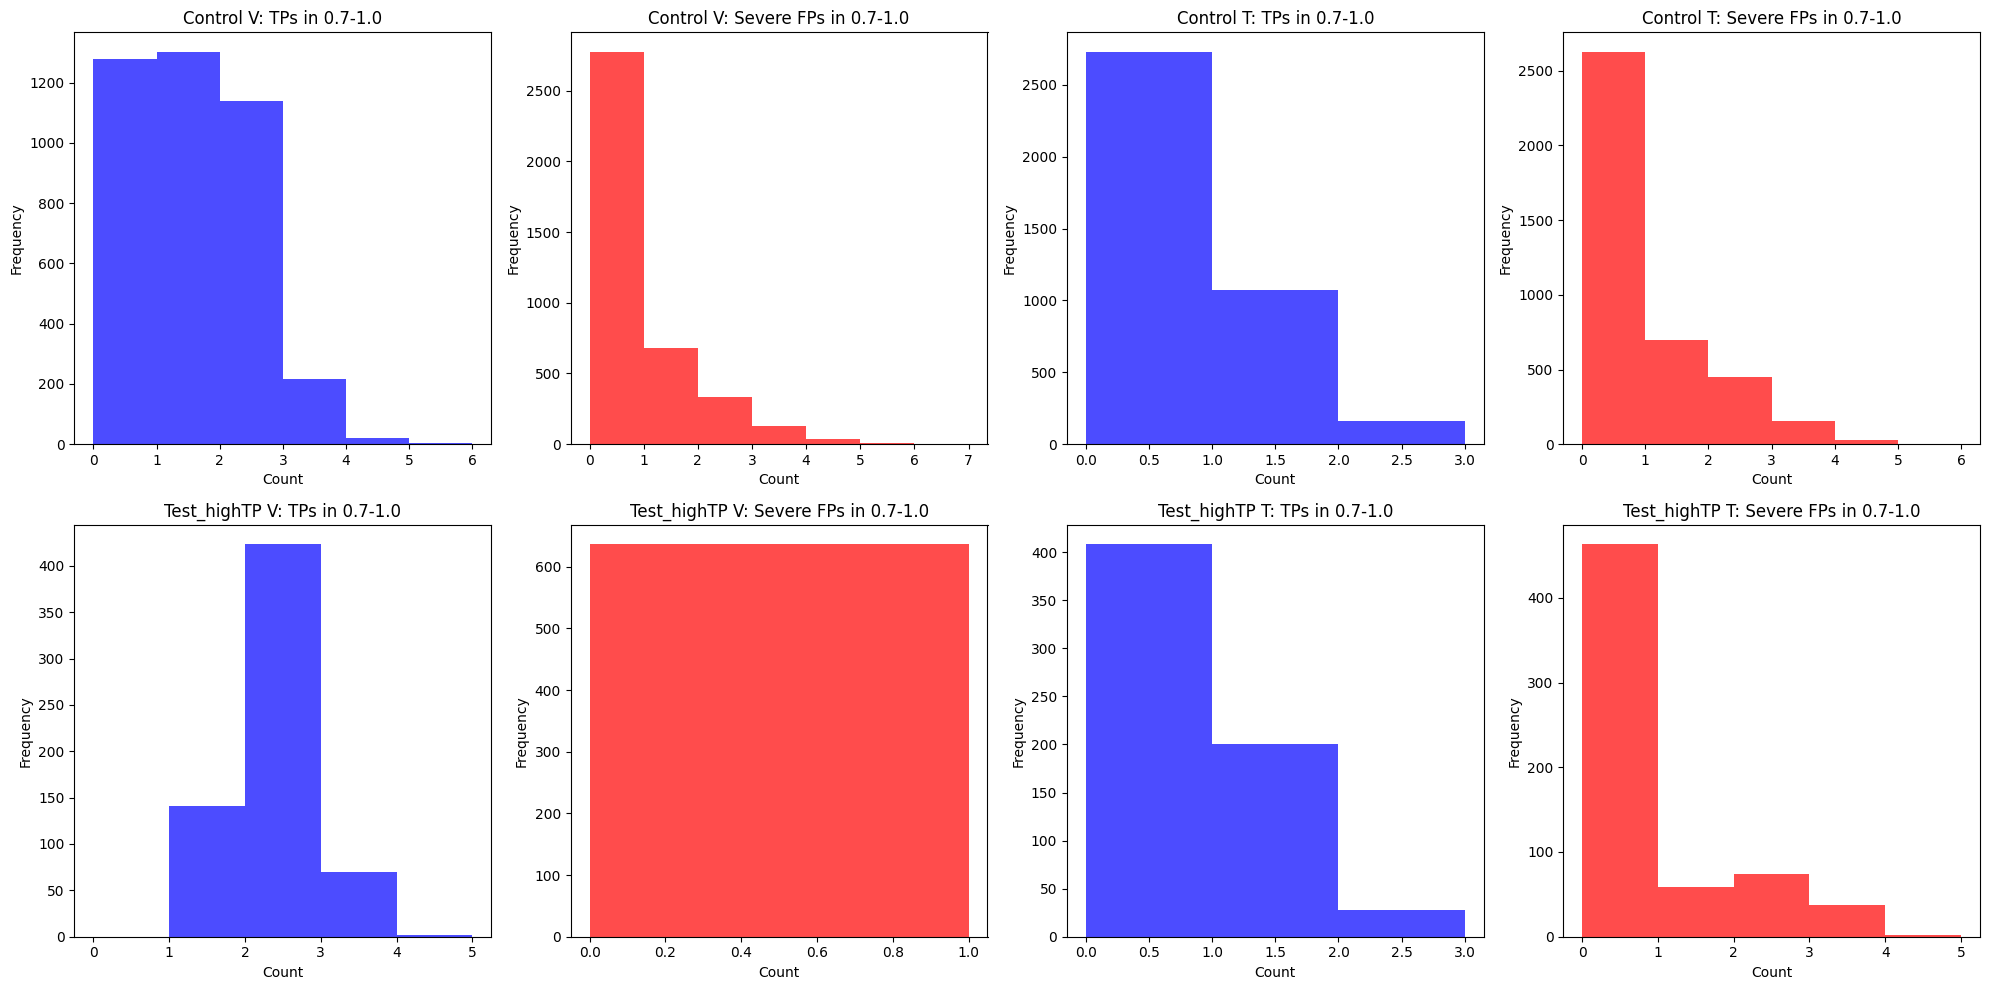

Control V seeds: 3962
Control T seeds: 3962
Test_highTP V seeds: 636
Test_highTP T seeds: 636

Severe FP Statistics:
Control V - Avg severe FPs: 0.49
Control T - Avg severe FPs: 0.55
Test_highTP V - Avg severe FPs: 0.00
Test_highTP T - Avg severe FPs: 0.52

Filtering check for test_highTP (max_severe_FPs_high_bracket=0):
Test_highTP V - Seeds with 0 severe FPs: 636/636
Test_highTP T - Seeds with 0 severe FPs: 463/636
Control T - Seeds with 0 severe FPs: 2626/3962


In [20]:
# Extract seed data from control models (V set)
control_v_high_bracket_tps = []
control_v_high_bracket_fps = []

for model in selected_models_control:
    for seed in model["selected_seeds"]:
        high_bracket = seed["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
        control_v_high_bracket_tps.append(high_bracket["TP"])
        control_v_high_bracket_fps.append(high_bracket["FP"])

# Extract seed data from control models (T set)
control_t_high_bracket_tps = []
control_t_high_bracket_fps = []

for model in selected_models_control_TEST:
    for seed in model["selected_seeds"]:
        high_bracket = seed["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
        control_t_high_bracket_tps.append(high_bracket["TP"])
        control_t_high_bracket_fps.append(high_bracket["FP"])

# Extract seed data from test_highTP models (V set)  
test_v_high_bracket_tps = []
test_v_high_bracket_fps = []

for model in selected_models_test_highTP:
    for seed in model["selected_seeds"]:
        high_bracket = seed["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
        test_v_high_bracket_tps.append(high_bracket["TP"])
        test_v_high_bracket_fps.append(high_bracket["FP"])

# Extract seed data from test_highTP models (T set)
test_t_high_bracket_tps = []
test_t_high_bracket_fps = []

for model in selected_models_test_highTP_TEST:
    for seed in model["selected_seeds"]:
        high_bracket = seed["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
        test_t_high_bracket_tps.append(high_bracket["TP"])
        test_t_high_bracket_fps.append(high_bracket["FP"])

# Create the 8 plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Control V set
axes[0,0].hist(control_v_high_bracket_tps, bins=range(0, max(control_v_high_bracket_tps)+2), alpha=0.7, color='blue')
axes[0,0].set_title('Control V: TPs in 0.7-1.0')
axes[0,1].hist(control_v_high_bracket_fps, bins=range(0, max(control_v_high_bracket_fps)+2), alpha=0.7, color='red')
axes[0,1].set_title('Control V: FPs in 0.7-1.0')

# Control T set
axes[0,2].hist(control_t_high_bracket_tps, bins=range(0, max(control_t_high_bracket_tps)+2), alpha=0.7, color='blue')
axes[0,2].set_title('Control T: TPs in 0.7-1.0')
axes[0,3].hist(control_t_high_bracket_fps, bins=range(0, max(control_t_high_bracket_fps)+2), alpha=0.7, color='red')
axes[0,3].set_title('Control T: FPs in 0.7-1.0')

# Test_highTP V set
axes[1,0].hist(test_v_high_bracket_tps, bins=range(0, max(test_v_high_bracket_tps)+2), alpha=0.7, color='blue')
axes[1,0].set_title('Test_highTP V: TPs in 0.7-1.0')
axes[1,1].hist(test_v_high_bracket_fps, bins=range(0, max(test_v_high_bracket_fps)+2), alpha=0.7, color='red')
axes[1,1].set_title('Test_highTP V: FPs in 0.7-1.0')

# Test_highTP T set
axes[1,2].hist(test_t_high_bracket_tps, bins=range(0, max(test_t_high_bracket_tps)+2), alpha=0.7, color='blue')
axes[1,2].set_title('Test_highTP T: TPs in 0.7-1.0')
axes[1,3].hist(test_t_high_bracket_fps, bins=range(0, max(test_t_high_bracket_fps)+2), alpha=0.7, color='red')
axes[1,3].set_title('Test_highTP T: FPs in 0.7-1.0')

# Set labels
for ax in axes.flat:
    ax.set(xlabel='Count', ylabel='Frequency')

plt.tight_layout()
plt.show()

# Print stats
print(f"Control V seeds: {len(control_v_high_bracket_tps)}")
print(f"Control T seeds: {len(control_t_high_bracket_tps)}")
print(f"Test_highTP V seeds: {len(test_v_high_bracket_tps)}")
print(f"Test_highTP T seeds: {len(test_t_high_bracket_tps)}")




###################

# Extract seed data from control models (V set)
control_v_high_bracket_tps = []
control_v_high_bracket_severe_fps = []  # Changed to severe FPs

for model in selected_models_control:
    for seed in model["selected_seeds"]:
        high_bracket = seed["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
        control_v_high_bracket_tps.append(high_bracket["TP"])
        control_v_high_bracket_severe_fps.append(seed["seed_severe_fp_high_bracket"])  # Severe FPs

# Extract seed data from control models (T set)
control_t_high_bracket_tps = []
control_t_high_bracket_severe_fps = []  # Changed to severe FPs

for model in selected_models_control_TEST:
    for seed in model["selected_seeds"]:
        high_bracket = seed["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
        control_t_high_bracket_tps.append(high_bracket["TP"])
        control_t_high_bracket_severe_fps.append(seed["seed_severe_fp_high_bracket"])  # Severe FPs

# Extract seed data from test_highTP models (V set)  
test_v_high_bracket_tps = []
test_v_high_bracket_severe_fps = []  # Changed to severe FPs

for model in selected_models_test_highTP:
    for seed in model["selected_seeds"]:
        high_bracket = seed["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
        test_v_high_bracket_tps.append(high_bracket["TP"])
        test_v_high_bracket_severe_fps.append(seed["seed_severe_fp_high_bracket"])  # Severe FPs

# Extract seed data from test_highTP models (T set)
test_t_high_bracket_tps = []
test_t_high_bracket_severe_fps = []  # Changed to severe FPs

for model in selected_models_test_highTP_TEST:
    for seed in model["selected_seeds"]:
        high_bracket = seed["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
        test_t_high_bracket_tps.append(high_bracket["TP"])
        test_t_high_bracket_severe_fps.append(seed["seed_severe_fp_high_bracket"])  # Severe FPs

# Create the 8 plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Control V set
axes[0,0].hist(control_v_high_bracket_tps, bins=range(0, max(control_v_high_bracket_tps)+2), alpha=0.7, color='blue')
axes[0,0].set_title('Control V: TPs in 0.7-1.0')
axes[0,1].hist(control_v_high_bracket_severe_fps, bins=range(0, max(control_v_high_bracket_severe_fps)+2), alpha=0.7, color='red')
axes[0,1].set_title('Control V: Severe FPs in 0.7-1.0')

# Control T set
axes[0,2].hist(control_t_high_bracket_tps, bins=range(0, max(control_t_high_bracket_tps)+2), alpha=0.7, color='blue')
axes[0,2].set_title('Control T: TPs in 0.7-1.0')
axes[0,3].hist(control_t_high_bracket_severe_fps, bins=range(0, max(control_t_high_bracket_severe_fps)+2), alpha=0.7, color='red')
axes[0,3].set_title('Control T: Severe FPs in 0.7-1.0')

# Test_highTP V set
axes[1,0].hist(test_v_high_bracket_tps, bins=range(0, max(test_v_high_bracket_tps)+2), alpha=0.7, color='blue')
axes[1,0].set_title('Test_highTP V: TPs in 0.7-1.0')
axes[1,1].hist(test_v_high_bracket_severe_fps, bins=range(0, max(test_v_high_bracket_severe_fps)+2), alpha=0.7, color='red')
axes[1,1].set_title('Test_highTP V: Severe FPs in 0.7-1.0')

# Test_highTP T set
axes[1,2].hist(test_t_high_bracket_tps, bins=range(0, max(test_t_high_bracket_tps)+2), alpha=0.7, color='blue')
axes[1,2].set_title('Test_highTP T: TPs in 0.7-1.0')
axes[1,3].hist(test_t_high_bracket_severe_fps, bins=range(0, max(test_t_high_bracket_severe_fps)+2), alpha=0.7, color='red')
axes[1,3].set_title('Test_highTP T: Severe FPs in 0.7-1.0')

# Set labels
for ax in axes.flat:
    ax.set(xlabel='Count', ylabel='Frequency')

plt.tight_layout()
plt.show()

# Print stats
print(f"Control V seeds: {len(control_v_high_bracket_tps)}")
print(f"Control T seeds: {len(control_t_high_bracket_tps)}")
print(f"Test_highTP V seeds: {len(test_v_high_bracket_tps)}")
print(f"Test_highTP T seeds: {len(test_t_high_bracket_tps)}")

# Print severe FP statistics
print(f"\nSevere FP Statistics:")
print(f"Control V - Avg severe FPs: {np.mean(control_v_high_bracket_severe_fps):.2f}")
print(f"Control T - Avg severe FPs: {np.mean(control_t_high_bracket_severe_fps):.2f}")
print(f"Test_highTP V - Avg severe FPs: {np.mean(test_v_high_bracket_severe_fps):.2f}")
print(f"Test_highTP T - Avg severe FPs: {np.mean(test_t_high_bracket_severe_fps):.2f}")

# Check if filtering worked correctly for test_highTP
print(f"\nFiltering check for test_highTP (max_severe_FPs_high_bracket=0):")
print(f"Test_highTP V - Seeds with 0 severe FPs: {sum(1 for x in test_v_high_bracket_severe_fps if x == 0)}/{len(test_v_high_bracket_severe_fps)}")
print(f"Test_highTP T - Seeds with 0 severe FPs: {sum(1 for x in test_t_high_bracket_severe_fps if x == 0)}/{len(test_t_high_bracket_severe_fps)}")


print(f"Control T - Seeds with 0 severe FPs: {sum(1 for x in control_t_high_bracket_severe_fps if x == 0)}/{len(control_t_high_bracket_severe_fps)}")

: 

: 

: 

: 

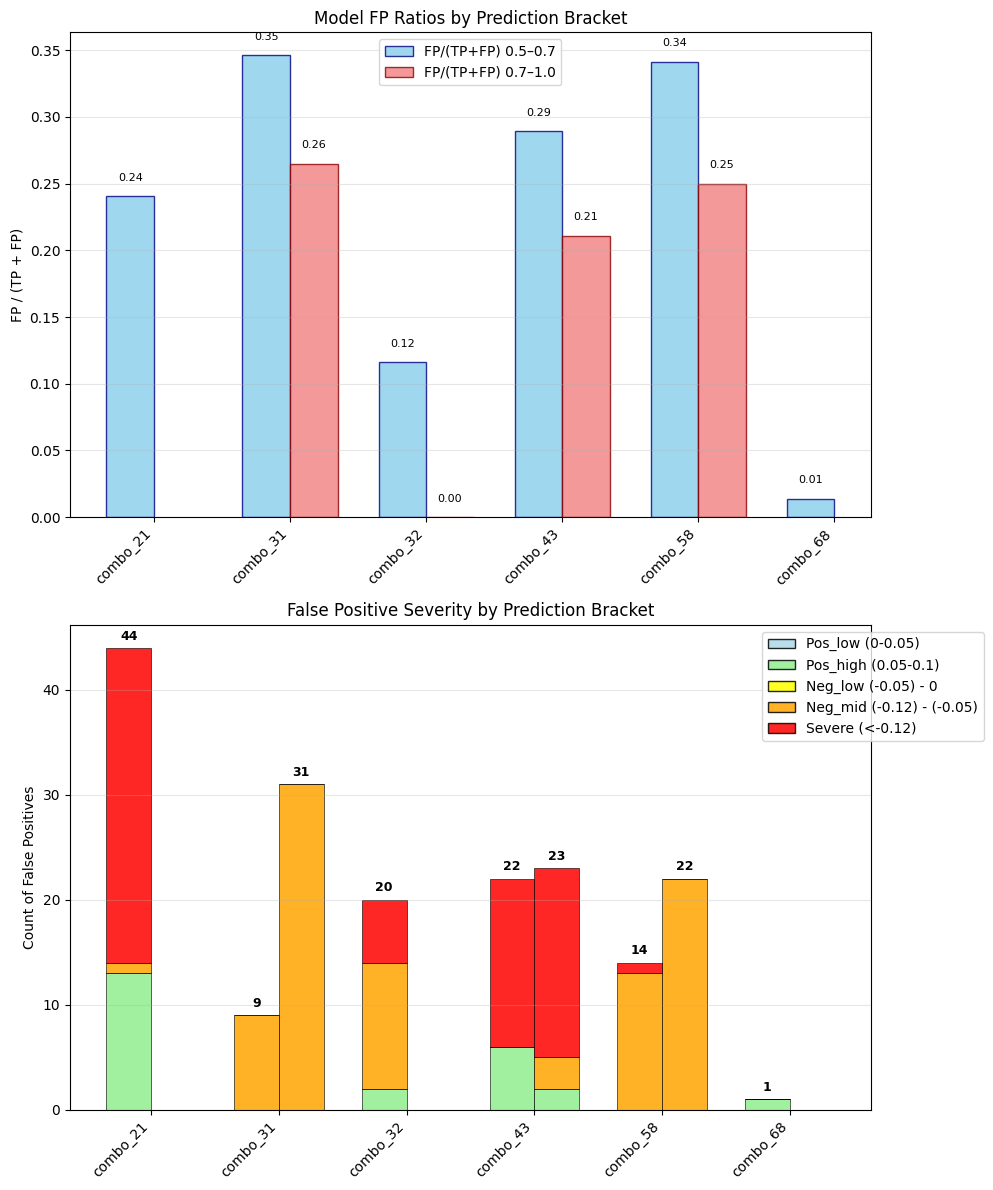

: 

: 

: 

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SEVERITY_CATS = [
    "Pos_low (0-0.05)",
    "Pos_high (0.05-0.1)",
    "Neg_low (-0.05) - 0",
    "Neg_mid (-0.12) - (-0.05)",
    "Severe (<-0.12)",
]
SEVERITY_COLORS = {
    "Pos_low (0-0.05)": 'lightblue',
    "Pos_high (0.05-0.1)": 'lightgreen',
    "Neg_low (-0.05) - 0": 'yellow',
    "Neg_mid (-0.12) - (-0.05)": 'orange',
    "Severe (<-0.12)": 'red',
    "Other": 'gray',
}

if not selected_models:
    print("No models to plot.")
else:
    labels = [f"combo_{m['combo_index']}" for m in selected_models]
    x = np.arange(len(labels))
    width = 0.35

    # --- Plot 1: FP Ratios (from fp_tp_ratios in selected_models) ---
    r_05_07 = [m.get("fp_tp_ratios", {}).get("0.5-0.7", np.nan) for m in selected_models]
    r_07_10 = [m.get("fp_tp_ratios", {}).get("0.7-1.0", np.nan) for m in selected_models]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, len(labels)*0.8), 12))

    b1 = ax1.bar(x - width/2, r_05_07, width, label='FP/(TP+FP) 0.5–0.7',
                 alpha=0.8, color='skyblue', edgecolor='navy')
    b2 = ax1.bar(x + width/2, r_07_10, width, label='FP/(TP+FP) 0.7–1.0',
                 alpha=0.8, color='lightcoral', edgecolor='darkred')
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.set_ylabel('FP / (TP + FP)'); ax1.set_title('Model FP Ratios by Prediction Bracket')
    ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

    for i, (v1, v2) in enumerate(zip(r_05_07, r_07_10)):
        if not np.isnan(v1): ax1.text(i - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', va='bottom', fontsize=8)
        if not np.isnan(v2): ax1.text(i + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', va='bottom', fontsize=8)

    # --- Plot 2: Severity Breakdown (read from fp_severity_by_bracket) ---
    # Build arrays directly from each model's fp_severity_by_bracket
    def get_counts(model, bracket_key, cat):
        d = model.get("fp_severity_by_bracket", {}).get(bracket_key, {})
        return int(d.get(cat, 0))

    low_data  = {cat: [get_counts(m, "0.5-0.7", cat) for m in selected_models] for cat in SEVERITY_CATS}
    high_data = {cat: [get_counts(m, "0.7-1.0", cat) for m in selected_models] for cat in SEVERITY_CATS}

    bottom_low  = np.zeros(len(labels))
    bottom_high = np.zeros(len(labels))
    legend_handles = []

    for cat in SEVERITY_CATS:
        color = SEVERITY_COLORS.get(cat, 'gray')
        ax2.bar(x - width/2, low_data[cat],  width, bottom=bottom_low,  color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        ax2.bar(x + width/2, high_data[cat], width, bottom=bottom_high, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        bottom_low  += np.array(low_data[cat])
        bottom_high += np.array(high_data[cat])
        legend_handles.append(plt.Rectangle((0,0), 1, 1, fc=color, alpha=0.85, label=cat, edgecolor='black'))

    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.set_ylabel('Count of False Positives')
    ax2.set_title('False Positive Severity by Prediction Bracket')
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3, axis='y')

    # Totals above bars
    total_low  = bottom_low
    total_high = bottom_high
    for i in range(len(labels)):
        if total_low[i]  > 0: ax2.text(i - width/2, total_low[i]  + 0.5, int(total_low[i]),  ha='center', va='bottom', fontsize=9, fontweight='bold')
        if total_high[i] > 0: ax2.text(i + width/2, total_high[i] + 0.5, int(total_high[i]), ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # # --- Summary printout using the same data (no raw re-walk) ---
    # print("\n" + "="*60)
    # print("SEVERE CASE PROPORTIONS BY BRACKET")
    # print("="*60)
    # for i, label in enumerate(labels):
    #     low_counts  = [low_data[cat][i]  for cat in SEVERITY_CATS]
    #     high_counts = [high_data[cat][i] for cat in SEVERITY_CATS]
    #     total_low   = sum(low_counts)
    #     total_high  = sum(high_counts)
    #     severe_low  = low_data["Severe (<-0.12)"][i]
    #     severe_high = high_data["Severe (<-0.12)"][i]

    #     prop_low  = (severe_low  / total_low  * 100) if total_low  > 0 else 0
    #     prop_high = (severe_high / total_high * 100) if total_high > 0 else 0

    #     print(f"{label}:")
    #     print(f"  Low bracket (0.5-0.7): {prop_low:.1f}% severe ({severe_low}/{total_low})")
    #     print(f"  High bracket (0.7-1.0): {prop_high:.1f}% severe ({severe_high}/{total_high})")
    #     print("-" * 40)


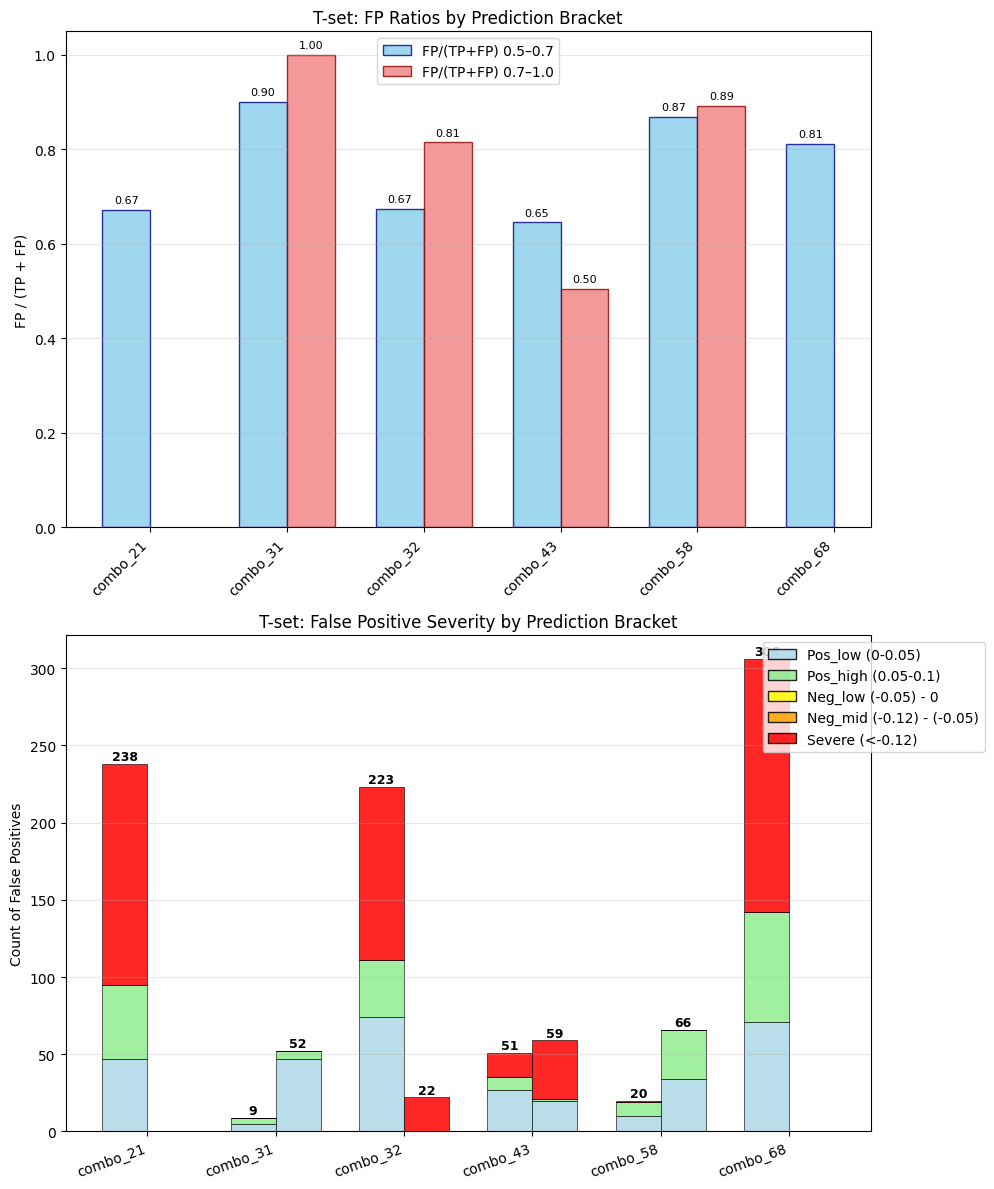

: 

: 

: 

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SEVERITY_CATS = [
    "Pos_low (0-0.05)",
    "Pos_high (0.05-0.1)",
    "Neg_low (-0.05) - 0",
    "Neg_mid (-0.12) - (-0.05)",
    "Severe (<-0.12)",
]
SEVERITY_COLORS = {
    "Pos_low (0-0.05)": 'lightblue',
    "Pos_high (0.05-0.1)": 'lightgreen',
    "Neg_low (-0.05) - 0": 'yellow',
    "Neg_mid (-0.12) - (-0.05)": 'orange',
    "Severe (<-0.12)": 'red',
    "Other": 'gray',
}

# 1) Get T-set metrics for the SAME selected models/seeds
tset_outputs = recompute_selected_models_on_Tset(
    results_dist_disc_Tset_same_seeds_organized,
    selected_models,
    brackets=((0.5, 0.7), (0.7, 1.0))
)

if not tset_outputs:
    print("No T-set models to plot.")
else:
    labels = [f"combo_{m['combo_index']}" for m in tset_outputs]
    x = np.arange(len(labels))
    width = 0.35

    # 2) Ratios directly from output
    r_05_07 = [m.get("fp_tp_ratios", {}).get("0.5-0.7", np.nan) for m in tset_outputs]
    r_07_10 = [m.get("fp_tp_ratios", {}).get("0.7-1.0", np.nan) for m in tset_outputs]

    # 3) Severity-by-bracket directly from output
    def get_counts(model, bracket_key, cat):
        return int(model.get("fp_severity_by_bracket", {}).get(bracket_key, {}).get(cat, 0))

    low_data  = {cat: [get_counts(m, "0.5-0.7", cat) for m in tset_outputs] for cat in SEVERITY_CATS}
    high_data = {cat: [get_counts(m, "0.7-1.0", cat) for m in tset_outputs] for cat in SEVERITY_CATS}

    # ----------------- PLOTS -----------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, len(labels)*0.8), 12))

    # Plot 1: FP ratios
    ax1.bar(x - width/2, r_05_07, width, label='FP/(TP+FP) 0.5–0.7',
            alpha=0.8, color='skyblue', edgecolor='navy', linewidth=1)
    ax1.bar(x + width/2, r_07_10, width, label='FP/(TP+FP) 0.7–1.0',
            alpha=0.8, color='lightcoral', edgecolor='darkred', linewidth=1)
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.set_ylabel('FP / (TP + FP)'); ax1.set_title('T-set: FP Ratios by Prediction Bracket')
    ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

    for i, (v1, v2) in enumerate(zip(r_05_07, r_07_10)):
        if not np.isnan(v1): ax1.text(i - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', va='bottom', fontsize=8)
        if not np.isnan(v2): ax1.text(i + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', va='bottom', fontsize=8)

    # Plot 2: Stacked FP severity by bracket
    bottom_low  = np.zeros(len(labels))
    bottom_high = np.zeros(len(labels))
    legend_handles = []

    for cat in SEVERITY_CATS:
        color = SEVERITY_COLORS.get(cat, 'gray')
        ax2.bar(x - width/2, low_data[cat],  width, bottom=bottom_low,  color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        ax2.bar(x + width/2, high_data[cat], width, bottom=bottom_high, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        bottom_low  += np.array(low_data[cat])
        bottom_high += np.array(high_data[cat])
        legend_handles.append(plt.Rectangle((0,0),1,1,fc=color,alpha=0.85,label=cat,edgecolor='black'))

    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=20, ha='right')
    ax2.set_ylabel('Count of False Positives')
    ax2.set_title('T-set: False Positive Severity by Prediction Bracket')
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3, axis='y')

    # Totals above bars
    for i in range(len(labels)):
        total_low  = int(sum(low_data[cat][i]  for cat in SEVERITY_CATS))
        total_high = int(sum(high_data[cat][i] for cat in SEVERITY_CATS))
        if total_low  > 0: ax2.text(i - width/2, total_low  + 0.5, total_low,  ha='center', va='bottom', fontsize=9, fontweight='bold')
        if total_high > 0: ax2.text(i + width/2, total_high + 0.5, total_high, ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # # ----------------- SUMMARY -----------------
    # print("\n" + "="*60)
    # print("SEVERE CASE PROPORTIONS BY BRACKET")
    # print("="*60)
    # for i, label in enumerate(labels):
    #     total_low  = int(sum(low_data[cat][i]  for cat in SEVERITY_CATS))
    #     total_high = int(sum(high_data[cat][i] for cat in SEVERITY_CATS))
    #     severe_low  = low_data["Severe (<-0.12)"][i]
    #     severe_high = high_data["Severe (<-0.12)"][i]
    #     prop_low  = (severe_low  / total_low  * 100) if total_low  > 0 else 0
    #     prop_high = (severe_high / total_high * 100) if total_high > 0 else 0
    #     print(f"{label}:")
    #     print(f"  Low bracket (0.5-0.7): {prop_low:.1f}% severe ({severe_low}/{total_low})")
    #     print(f"  High bracket (0.7-1.0): {prop_high:.1f}% severe ({severe_high}/{total_high})")
    #     print("-" * 40)


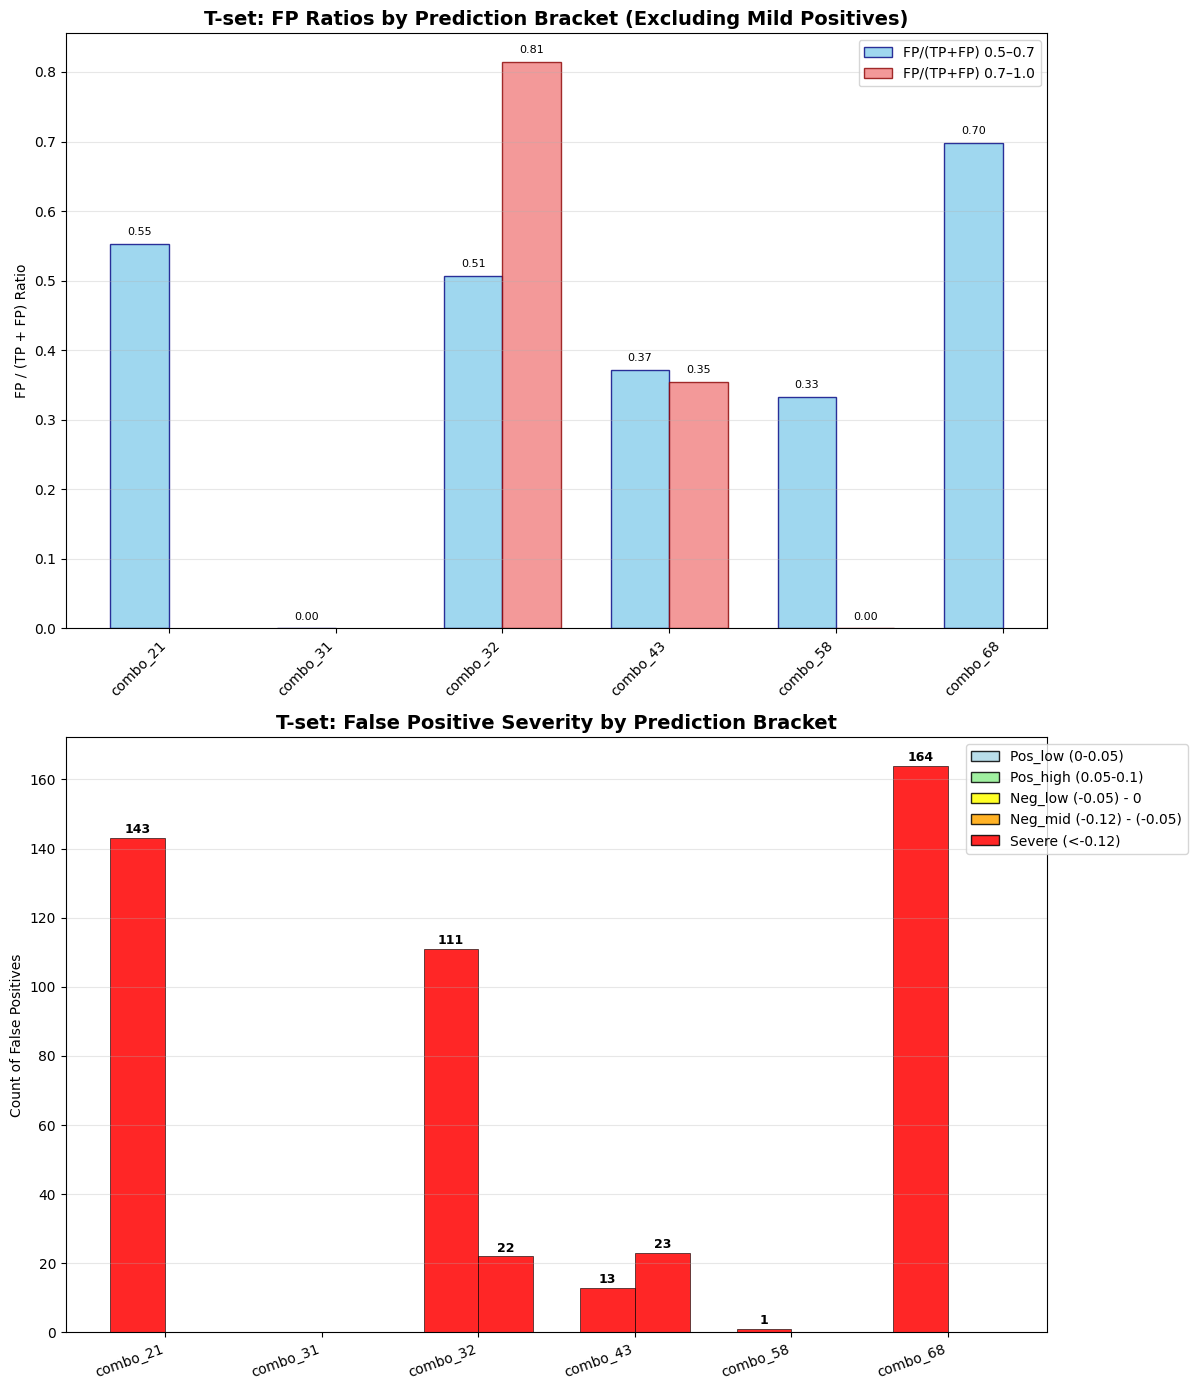

: 

: 

: 

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SEVERITY_CATS = [
    "Pos_low (0-0.05)",
    "Pos_high (0.05-0.1)",
    "Neg_low (-0.05) - 0",
    "Neg_mid (-0.12) - (-0.05)",
    "Severe (<-0.12)",
]
SEVERITY_COLORS = {
    "Pos_low (0-0.05)": 'lightblue',
    "Pos_high (0.05-0.1)": 'lightgreen',
    "Neg_low (-0.05) - 0": 'yellow',
    "Neg_mid (-0.12) - (-0.05)": 'orange',
    "Severe (<-0.12)": 'red',
    "Other": 'gray',
}

# --- Build T-set metrics using the helpers you already have ---
# 1) Baseline: keep Pos_low/Pos_high FPs
tset_keep = recompute_metrics_ignoring_pos_fp(
    selected_models_output=selected_models,
    results_data=results_dist_disc_Tset_same_seeds_organized,
    targets=("pos_low", "pos_high"),
    fp_treatment="keep",
)

# 2) Exclude mild positives: ignore Pos_low/Pos_high FPs
tset_ignore = recompute_metrics_ignoring_pos_fp(
    selected_models_output=selected_models,
    results_data=results_dist_disc_Tset_same_seeds_organized,
    targets=("pos_low", "pos_high"),
    fp_treatment="ignore",
)

if not tset_keep:
    print("No T-set models to plot.")
else:
    labels = [f"combo_{m['combo_index']}" for m in tset_keep]
    x = np.arange(len(labels))
    width = 0.35

    def get_ratio(models, key):
        return [m.get("fp_tp_ratios", {}).get(key, np.nan) for m in models]

    # choose which set to visualize
    EXCLUDE_MILD_POSITIVES = True  # toggle here
    current = tset_ignore if EXCLUDE_MILD_POSITIVES else tset_keep
    title_suffix = " (Excluding Mild Positives)" if EXCLUDE_MILD_POSITIVES else " (All FPs)"

    r_05_07 = get_ratio(current, "0.5-0.7")
    r_07_10 = get_ratio(current, "0.7-1.0")

    # severity-by-bracket from the model outputs
    def get_counts(model, bracket_key, cat):
        return int(model.get("fp_severity_by_bracket", {}).get(bracket_key, {}).get(cat, 0))

    low_data  = {cat: [get_counts(m, "0.5-0.7", cat) for m in current] for cat in SEVERITY_CATS}
    high_data = {cat: [get_counts(m, "0.7-1.0", cat) for m in current] for cat in SEVERITY_CATS}

    # ----------------- PLOTS -----------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(12, len(labels)*0.8), 14))

    # Plot 1: FP ratios
    ax1.bar(x - width/2, r_05_07, width, label='FP/(TP+FP) 0.5–0.7',
            alpha=0.8, color='skyblue', edgecolor='navy', linewidth=1)
    ax1.bar(x + width/2, r_07_10, width, label='FP/(TP+FP) 0.7–1.0',
            alpha=0.8, color='lightcoral', edgecolor='darkred', linewidth=1)
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.set_ylabel('FP / (TP + FP) Ratio')
    ax1.set_title(f'T-set: FP Ratios by Prediction Bracket{title_suffix}', fontsize=14, fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

    for i, (v1, v2) in enumerate(zip(r_05_07, r_07_10)):
        if not np.isnan(v1): ax1.text(i - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', va='bottom', fontsize=8)
        if not np.isnan(v2): ax1.text(i + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', va='bottom', fontsize=8)

    # Plot 2: stacked FP severity by bracket
    bottom_low  = np.zeros(len(labels))
    bottom_high = np.zeros(len(labels))
    legend_handles = []

    for cat in SEVERITY_CATS:
        color = SEVERITY_COLORS.get(cat, 'gray')
        ax2.bar(x - width/2, low_data[cat],  width, bottom=bottom_low,  color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        ax2.bar(x + width/2, high_data[cat], width, bottom=bottom_high, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        bottom_low  += np.array(low_data[cat])
        bottom_high += np.array(high_data[cat])
        legend_handles.append(plt.Rectangle((0,0), 1, 1, fc=color, alpha=0.85, label=cat, edgecolor='black'))

    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=20, ha='right')
    ax2.set_ylabel('Count of False Positives')
    ax2.set_title('T-set: False Positive Severity by Prediction Bracket', fontsize=14, fontweight='bold')
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3, axis='y')

    # Totals above bars
    for i in range(len(labels)):
        total_low  = int(sum(low_data[cat][i]  for cat in SEVERITY_CATS))
        total_high = int(sum(high_data[cat][i] for cat in SEVERITY_CATS))
        if total_low  > 0: ax2.text(i - width/2, total_low  + 0.5, total_low,  ha='center', va='bottom', fontsize=9, fontweight='bold')
        if total_high > 0: ax2.text(i + width/2, total_high + 0.5, total_high, ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # # ----------------- COMPARISON PRINT (keep vs ignore) -----------------
    # print("\n" + "="*60)
    # print("COMPARISON: FP RATIOS WITH vs WITHOUT MILD POSITIVES (T-set)")
    # print("="*60)
    # base_05_07 = get_ratio(tset_keep,   "0.5-0.7")
    # base_07_10 = get_ratio(tset_keep,   "0.7-1.0")
    # ign_05_07  = get_ratio(tset_ignore, "0.5-0.7")
    # ign_07_10  = get_ratio(tset_ignore, "0.7-1.0")

    # for i, label in enumerate(labels):
    #     b1, b2 = base_05_07[i], base_07_10[i]
    #     n1, n2 = ign_05_07[i],  ign_07_10[i]
    #     if not (np.isnan(b1) or np.isnan(n1) or np.isnan(b2) or np.isnan(n2)):
    #         print(f"{label}:")
    #         print(f"  0.5-0.7: {b1:.3f} → {n1:.3f} (Δ={n1-b1:+.3f})")
    #         print(f"  0.7-1.0: {b2:.3f} → {n2:.3f} (Δ={n2-b2:+.3f})")
    #         print("-" * 30)


In [ ]:
selected_models = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=70,
    min_ratio_difference= None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs= None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,  # NEW: Add the parameter here
    random_seed=42,
    max_models_to_return=70
)

: 

: 

: 

: 

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_41856/2382887675.py:136: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot(pdata, labels=['Original', 'Exclude', 'Reclassify'])


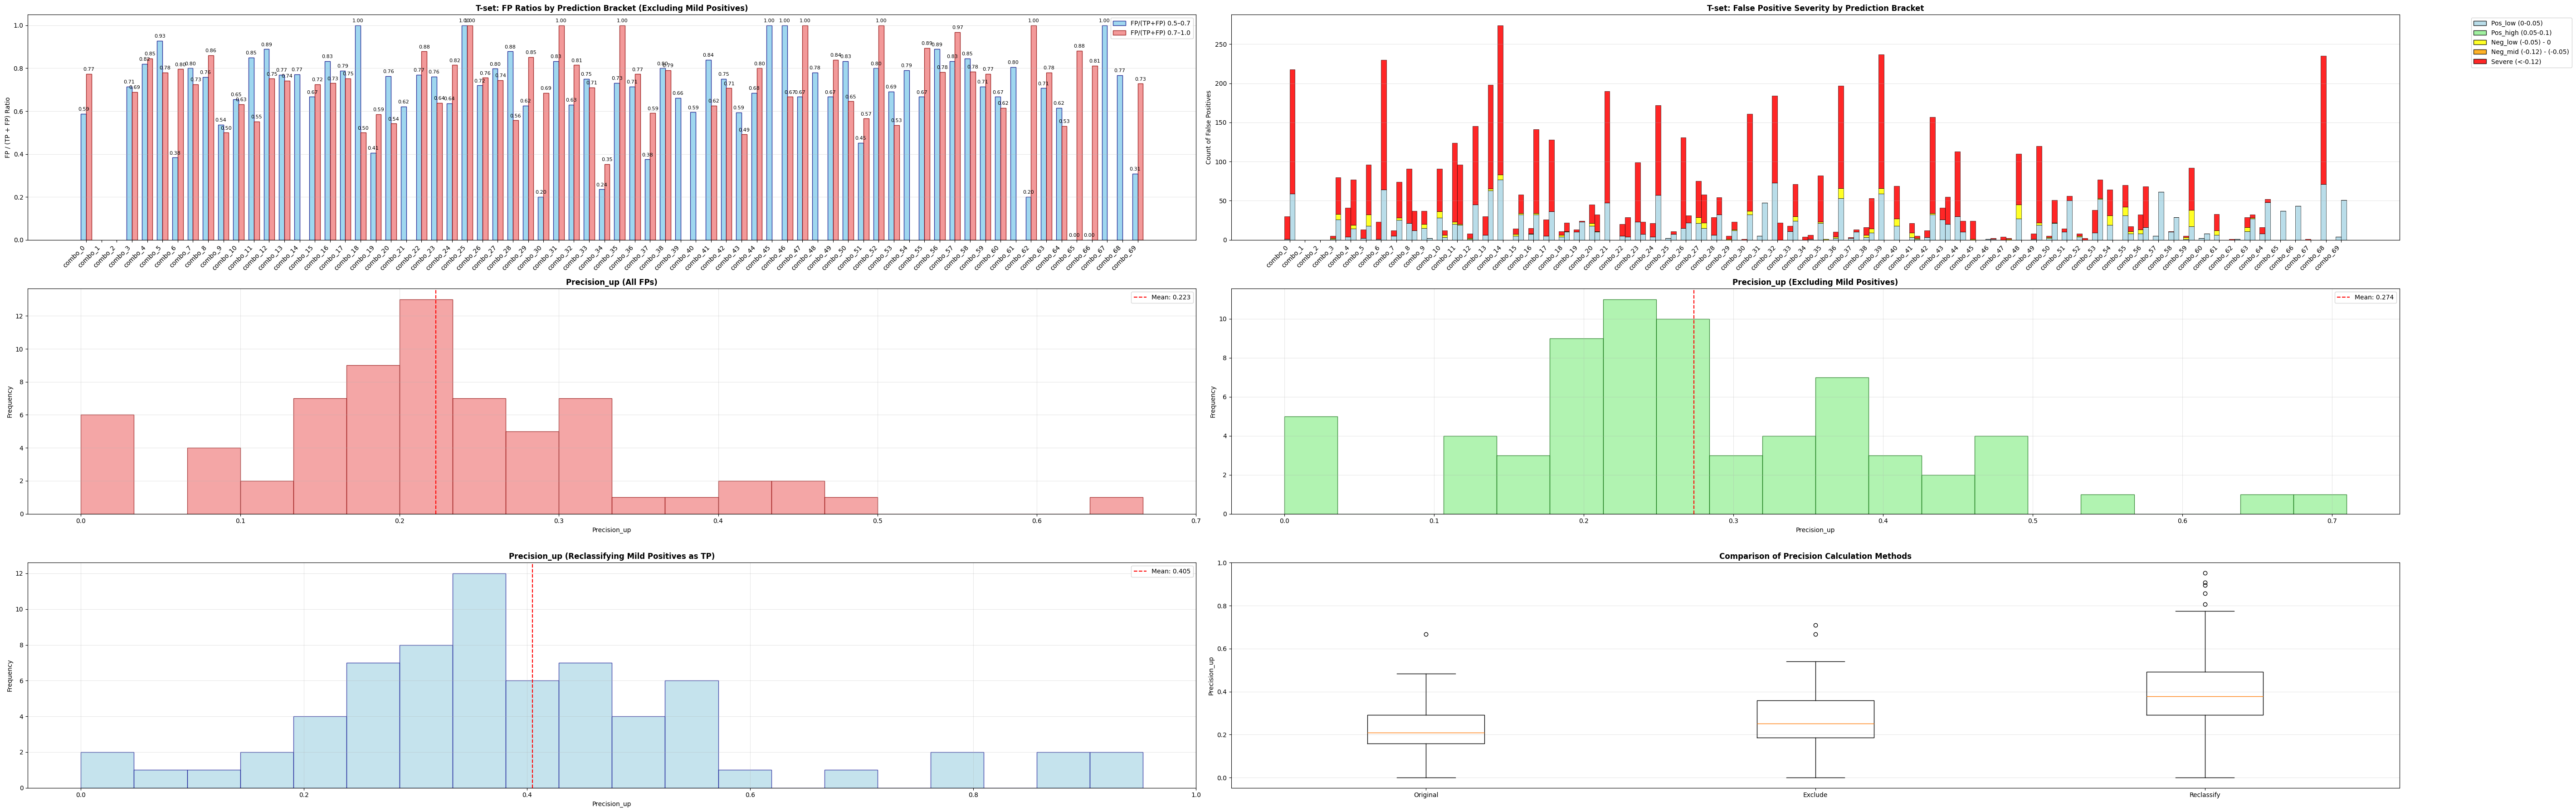

: 

: 

: 

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SEVERITY_CATS = [
    "Pos_low (0-0.05)",
    "Pos_high (0.05-0.1)",
    "Neg_low (-0.05) - 0",
    "Neg_mid (-0.12) - (-0.05)",
    "Severe (<-0.12)",
]
SEVERITY_COLORS = {
    "Pos_low (0-0.05)": 'lightblue',
    "Pos_high (0.05-0.1)": 'lightgreen',
    "Neg_low (-0.05) - 0": 'yellow',
    "Neg_mid (-0.12) - (-0.05)": 'orange',
    "Severe (<-0.12)": 'red',
    "Other": 'gray',
}

# --- 1) Build T-set metrics using the helper (no raw loops) ---
tset_keep = recompute_metrics_ignoring_pos_fp(
    selected_models_output=selected_models,
    results_data=results_dist_disc_Tset_same_seeds_organized,
    targets=("pos_low", "pos_high"),
    fp_treatment="keep",          # baseline, count all FPs as-is
)

# tset_keep = recompute_selected_models_on_Tset(results_dist_disc_Tset_same_seeds_organized,
#                                       selected_models,
#                                       brackets=((0.5, 0.7), (0.7, 1.0)))

tset_ignore = recompute_metrics_ignoring_pos_fp(
    selected_models_output=selected_models,
    results_data=results_dist_disc_Tset_same_seeds_organized,
    targets=("pos_high"),
    fp_treatment="ignore",        # drop Pos_low / Pos_high FPs entirely
)
tset_flip = recompute_metrics_ignoring_pos_fp(
    selected_models_output=selected_models,
    results_data=results_dist_disc_Tset_same_seeds_organized,
    targets=("pos_high"),
    fp_treatment="flip_to_tp",    # reclassify Pos_low / Pos_high FPs as TPs
)

if not tset_keep:
    print("No T-set models to plot.")
else:
    # pick which variant to visualize in the charts
    VIEW = "ignore"  # one of: "keep", "ignore", "flip_to_tp"
    current = {"keep": tset_keep, "ignore": tset_ignore, "flip_to_tp": tset_flip}[VIEW]
    title_suffix = {
        "keep": " (All FPs)",
        "ignore": " (Excluding Mild Positives)",
        "flip_to_tp": " (Reclassifying Mild Positives as TP)",
    }[VIEW]

    labels = [f"combo_{m['combo_index']}" for m in current]
    x = np.arange(len(labels))
    width = 0.35

    def get_ratio(models, key):
        return [m.get("fp_tp_ratios", {}).get(key, np.nan) for m in models]

    r_05_07 = get_ratio(current, "0.5-0.7")
    r_07_10 = get_ratio(current, "0.7-1.0")

    def get_counts(model, bracket_key, cat):
        return int(model.get("fp_severity_by_bracket", {}).get(bracket_key, {}).get(cat, 0))

    low_data  = {cat: [get_counts(m, "0.5-0.7", cat) for m in current] for cat in SEVERITY_CATS}
    high_data = {cat: [get_counts(m, "0.7-1.0", cat) for m in current] for cat in SEVERITY_CATS}

    # precision distributions from mean_precision (already recomputed under each policy)
    precis_keep   = [m["mean_precision"] for m in tset_keep   if not np.isnan(m["mean_precision"])]
    precis_ignore = [m["mean_precision"] for m in tset_ignore if not np.isnan(m["mean_precision"])]
    precis_flip   = [m["mean_precision"] for m in tset_flip   if not np.isnan(m["mean_precision"])]

    # severe FP counts per model (sum both brackets)
    severe_counts = [
        sum(get_counts(m, b, "Severe (<-0.12)") for b in ("0.5-0.7", "0.7-1.0"))
        for m in current
    ]

    # ----------------- PLOTS (4x2 trimmed & cleaner) -----------------
    fig, axes = plt.subplots(3, 2, figsize=(max(16, len(labels)*0.8), 18))
    ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

    # Plot 1: FP ratios
    ax1.bar(x - width/2, r_05_07, width, label='FP/(TP+FP) 0.5–0.7',
            alpha=0.8, color='skyblue', edgecolor='navy', linewidth=1)
    ax1.bar(x + width/2, r_07_10, width, label='FP/(TP+FP) 0.7–1.0',
            alpha=0.8, color='lightcoral', edgecolor='darkred', linewidth=1)
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.set_ylabel('FP / (TP + FP) Ratio')
    ax1.set_title(f'T-set: FP Ratios by Prediction Bracket{title_suffix}', fontsize=12, fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')
    for i, (v1, v2) in enumerate(zip(r_05_07, r_07_10)):
        if not np.isnan(v1): ax1.text(i - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', va='bottom', fontsize=8)
        if not np.isnan(v2): ax1.text(i + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', va='bottom', fontsize=8)

    # Plot 2: Stacked severity by bracket
    bottom_low  = np.zeros(len(labels))
    bottom_high = np.zeros(len(labels))
    legend_handles = []
    for cat in SEVERITY_CATS:
        color = SEVERITY_COLORS.get(cat, 'gray')
        ax2.bar(x - width/2, low_data[cat],  width, bottom=bottom_low,  color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        ax2.bar(x + width/2, high_data[cat], width, bottom=bottom_high, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        bottom_low  += np.array(low_data[cat])
        bottom_high += np.array(high_data[cat])
        legend_handles.append(plt.Rectangle((0,0),1,1,fc=color,alpha=0.85,label=cat,edgecolor='black'))
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.set_ylabel('Count of False Positives')
    ax2.set_title('T-set: False Positive Severity by Prediction Bracket', fontsize=12, fontweight='bold')
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.15, 1))
    ax2.grid(True, alpha=0.3, axis='y')

    # Plot 3–5: Precision distributions under each policy
    def plot_hist(ax, data, title, color, edge):
        if data:
            ax.hist(data, bins=20, alpha=0.7, color=color, edgecolor=edge)
            ax.axvline(np.mean(data), color='red', linestyle='--', label=f'Mean: {np.mean(data):.3f}')
            ax.set_xlabel('Precision_up'); ax.set_ylabel('Frequency')
            ax.set_title(title, fontsize=12, fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No valid precision data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title, fontsize=12, fontweight='bold')

    plot_hist(ax3, precis_keep,   'Precision_up (All FPs)',                          'lightcoral', 'darkred')
    plot_hist(ax4, precis_ignore, 'Precision_up (Excluding Mild Positives)',         'lightgreen', 'darkgreen')
    plot_hist(ax5, precis_flip,   'Precision_up (Reclassifying Mild Positives as TP)','lightblue', 'darkblue')

    # Plot 6: Comparison boxplot
    pdata = [precis_keep, precis_ignore, precis_flip]
    if all(len(d) > 0 for d in pdata):
        ax6.boxplot(pdata, labels=['Original', 'Exclude', 'Reclassify'])
        ax6.set_ylabel('Precision_up')
        ax6.set_title('Comparison of Precision Calculation Methods', fontsize=12, fontweight='bold')
        ax6.grid(True, alpha=0.3, axis='y')
    else:
        ax6.text(0.5, 0.5, 'Insufficient data for comparison', ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('Comparison of Precision Calculation Methods', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # # ----------------- TEXT SUMMARY -----------------
    # print("\n" + "="*60)
    # print("SEVERE CASE PROPORTIONS BY BRACKET (current view)")
    # print("="*60)
    # for i, label in enumerate(labels):
    #     total_low  = sum(low_data[cat][i]  for cat in SEVERITY_CATS)
    #     total_high = sum(high_data[cat][i] for cat in SEVERITY_CATS)
    #     severe_low  = low_data["Severe (<-0.12)"][i]
    #     severe_high = high_data["Severe (<-0.12)"][i]
    #     prop_low  = (severe_low  / total_low  * 100) if total_low  > 0 else 0
    #     prop_high = (severe_high / total_high * 100) if total_high > 0 else 0
    #     print(f"{label}:")
    #     print(f"  Low bracket (0.5-0.7): {prop_low:.1f}% severe ({severe_low}/{total_low})")
    #     print(f"  High bracket (0.7-1.0): {prop_high:.1f}% severe ({severe_high}/{total_high})")
    #     print("-" * 40)

    # print("\n" + "="*60)
    # print("PRECISION COMPARISON (means)")
    # print("="*60)
    # def mean_n(data): 
    #     return (np.mean(data), len(data)) if data else (np.nan, 0)
    # m0,n0 = mean_n(precis_keep);   print(f"Original:     Mean = {m0:.3f} (n={n0})")
    # m1,n1 = mean_n(precis_ignore); print(f"Exclude mild: Mean = {m1:.3f} (n={n1})")
    # m2,n2 = mean_n(precis_flip);   print(f"Reclassify:   Mean = {m2:.3f} (n={n2})")
    # if n0 and n1: print(f"Exclude vs Original: Δ = {m1-m0:+.3f}")
    # if n0 and n2: print(f"Reclassify vs Original: Δ = {m2-m0:+.3f}")

    # print("\n" + "="*60)
    # print("SEVERE FALSE POSITIVES COUNT BY MODEL (current view)")
    # print("="*60)
    # for label, cnt in zip(labels, severe_counts):
    #     print(f"{label}: {cnt}")




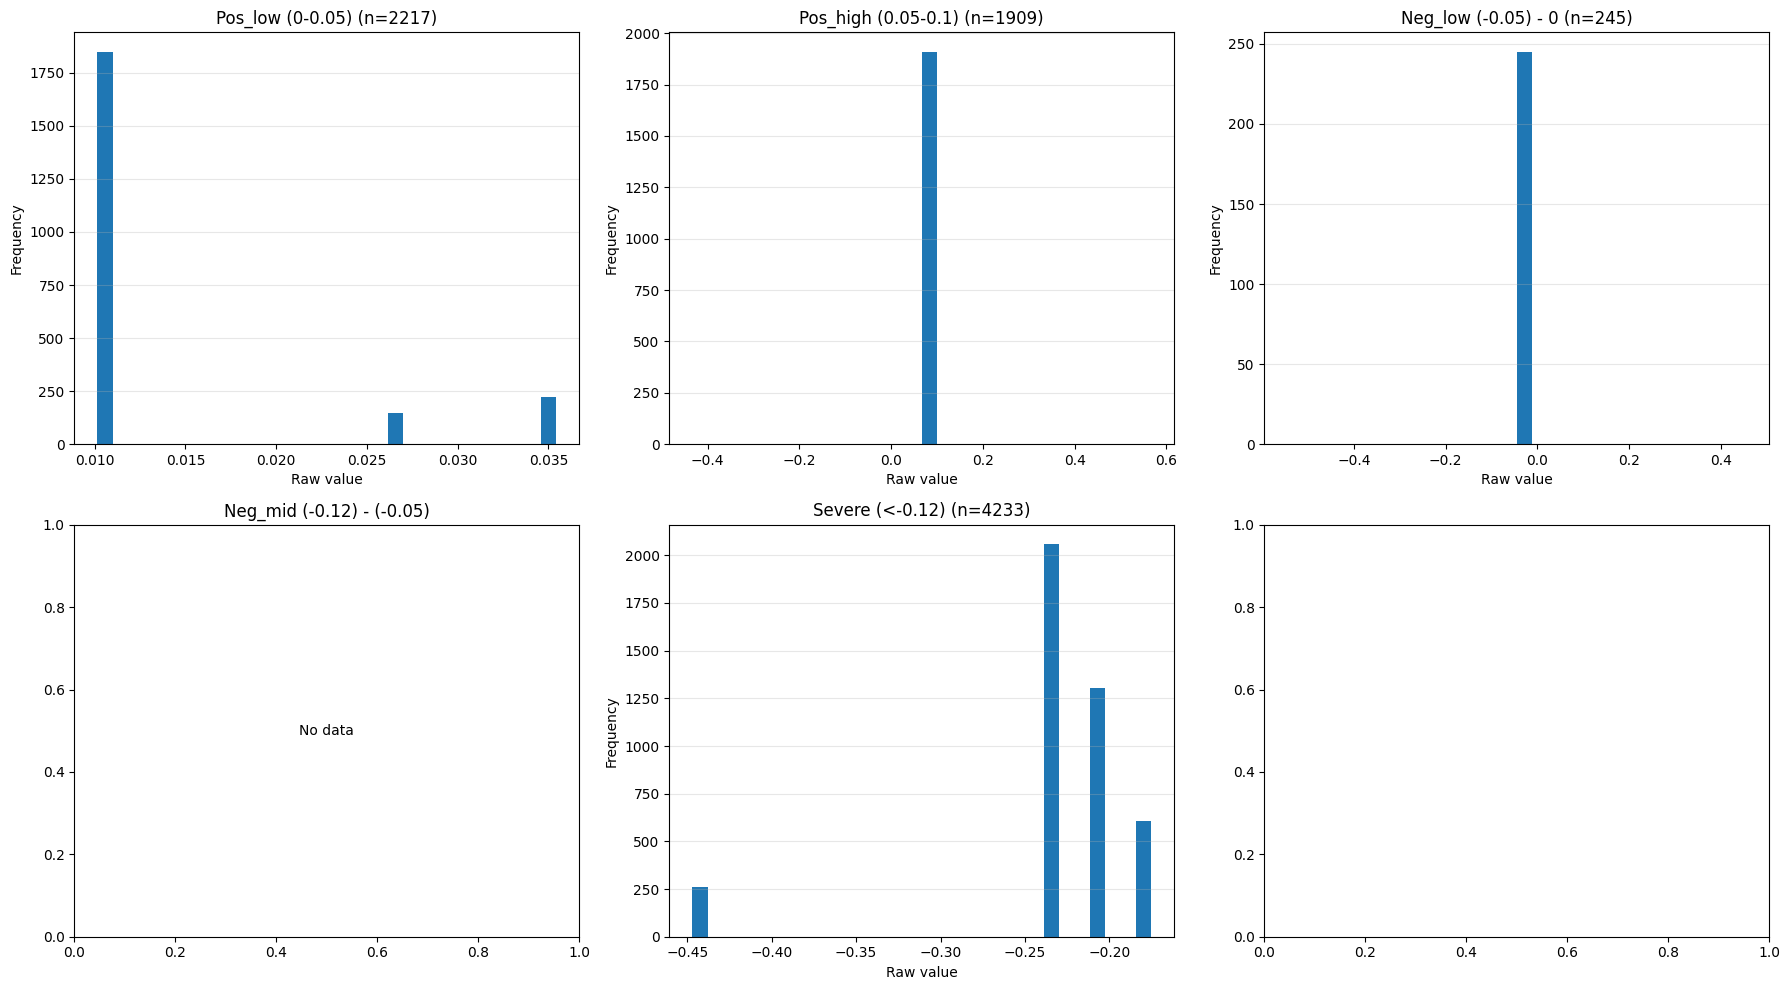

: 

: 

: 

: 

In [ ]:
# --- NEW: Distributions using ONLY tset_keep ---

# 1) Collect FP raw values by severity (collapse across pred brackets)
severity_raws = {cat: [] for cat in SEVERITY_CATS}

for m in tset_keep:
    raw_map = m.get("fp_severity_by_bracket_raw_vals", {})  # {"0.5-0.7": {cat:[...]}, "0.7-1.0": {...}}
    for br_map in raw_map.values():                          # iterate both brackets (if present)
        for cat in SEVERITY_CATS:
            vals = br_map.get(cat, [])
            if vals:
                severity_raws[cat].extend(vals)


# 3) Plot: one histogram per severity + one for TP raws
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
axes2 = axes2.flatten()

# Severities (5 plots)
for i, cat in enumerate(SEVERITY_CATS):
    data = severity_raws[cat]
    ax = axes2[i]
    if data:
        ax.hist(data, bins=30)
        ax.set_title(f"{cat} (n={len(data)})")
        ax.set_xlabel("Raw value"); ax.set_ylabel("Frequency")
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(cat)


plt.tight_layout()
plt.show()


: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

---
# Testing and Older Funcs 
---

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10478d940>>
Traceback (most recent call last):
  File "/Users/cs/venvs/venv_1/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


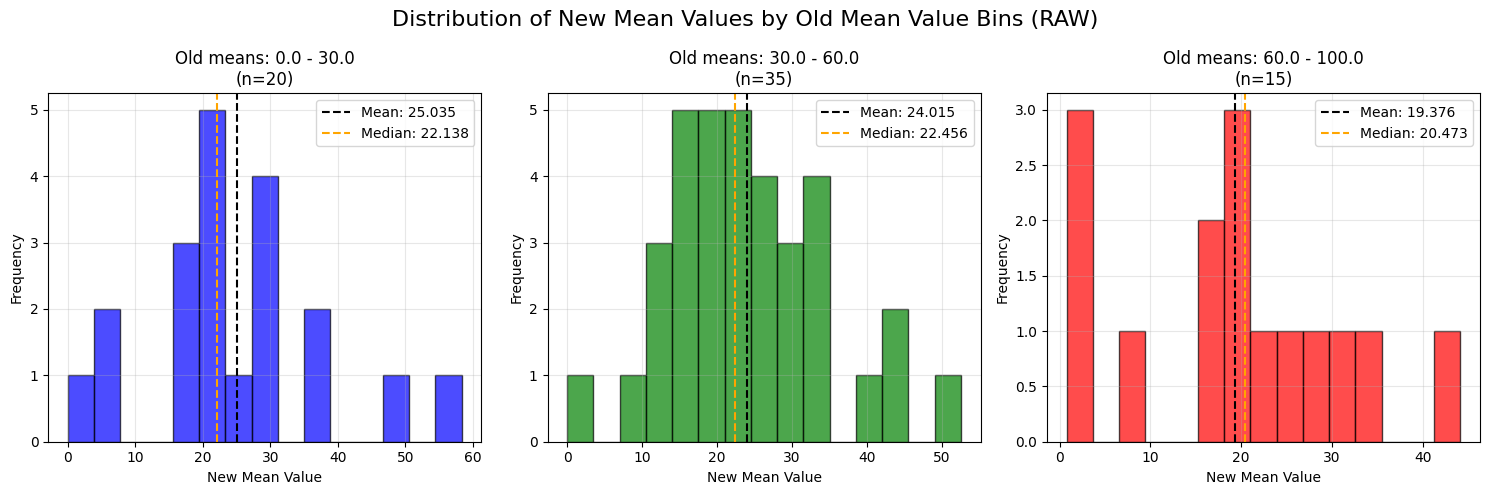

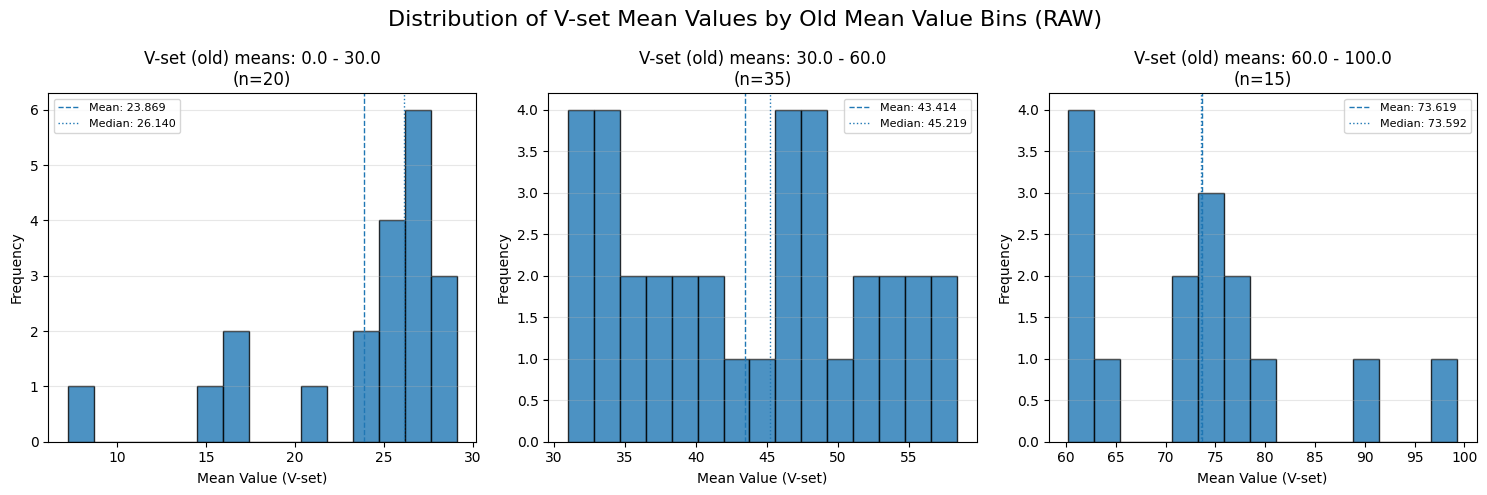

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_41856/682045836.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_new_means, labels=all_labels)


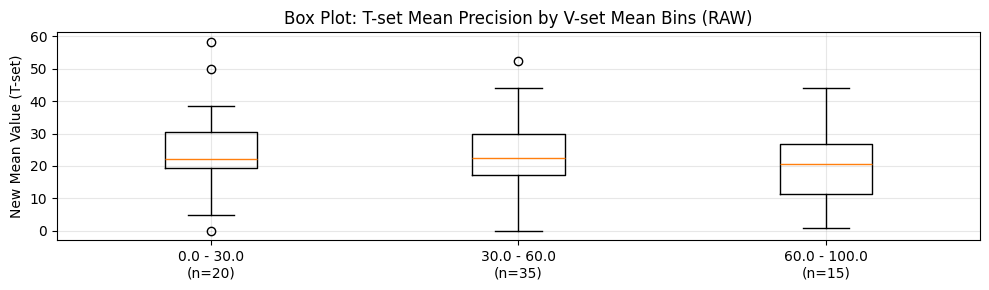

Statistics by Old (V-set) Mean Bin [RAW]:

Bin: 0.0 - 30.0
  Count: 20
  T-set mean - Mean:   25.0348
  T-set mean - Median: 22.1383
  T-set mean - Std:    13.4956
  T-set mean - Min:    0.0000
  T-set mean - Max:    58.3333
  V-set mean - Mean:   23.8690

Bin: 30.0 - 60.0
  Count: 35
  T-set mean - Mean:   24.0155
  T-set mean - Median: 22.4558
  T-set mean - Std:    10.6429
  T-set mean - Min:    0.0000
  T-set mean - Max:    52.5439
  V-set mean - Mean:   43.4140

Bin: 60.0 - 100.0
  Count: 15
  T-set mean - Mean:   19.3764
  T-set mean - Median: 20.4728
  T-set mean - Std:    12.3034
  T-set mean - Min:    0.7692
  T-set mean - Max:    44.1422
  V-set mean - Mean:   73.6186


: 

: 

: 

: 

In [ ]:
# =========================
# RAW DATA VERSION (SANITY)
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Inputs expected to exist:
#   v_mean      -> V-set model mean precisions (OLD)
#   v_new_mean  -> T-set model mean precisions (NEW)
# No function calls here; use raw arrays as requested.

# Extract & sanitize inputs
old = np.asarray(v_mean, dtype=float)
new = np.asarray(v_new_mean, dtype=float)

# 1) Drop NaN/Inf in lockstep (keep only pairs where both are finite)
valid = np.isfinite(old) & np.isfinite(new)
old = old[valid]
new = new[valid]

# 2) Define binning using np.digitize for consistent boundaries
# Bins: [0,30), [30,60), [60, +inf)
bin_edges = np.array([0.0, 30.0, 60.0, np.inf])
bin_idx = np.digitize(old, bin_edges, right=False) - 1  # -> 0,1,2

range_labels = ['0.0 - 30.0', '30.0 - 60.0', '60.0 - 100.0']
colors = ['blue', 'green', 'red']  # optional

# ----------------- Figure 1: T-set (new) distributions per OLD-mean bin -----------------
plt.figure(figsize=(15, 5))
for i, (label, color) in enumerate(zip(range_labels, colors)):
    mask = (bin_idx == i)
    new_r = new[mask]

    ax = plt.subplot(1, 3, i + 1)
    if new_r.size > 0:
        plt.hist(new_r, bins=15, alpha=0.7, color=color, edgecolor='black')
        mean_v = float(np.mean(new_r))
        med_v  = float(np.median(new_r))
        plt.axvline(mean_v, color='black', linestyle='--', label=f'Mean: {mean_v:.3f}')
        plt.axvline(med_v,  color='orange', linestyle='--', label=f'Median: {med_v:.3f}')
        plt.title(f'Old means: {label}\n(n={new_r.size})')
        plt.xlabel('New Mean Value')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No data in range\n{label}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Old means: {label}')

plt.suptitle('Distribution of New Mean Values by Old Mean Value Bins (RAW)', fontsize=16)
plt.tight_layout()
plt.show()

# ----------------- Figure 2: V-set (old) distributions per OLD-mean bin -----------------
plt.figure(figsize=(15, 5))
for i, (label, color) in enumerate(zip(range_labels, colors)):
    mask = (bin_idx == i)
    old_r = old[mask]

    ax = plt.subplot(1, 3, i + 1)
    if old_r.size > 0:
        plt.hist(old_r, bins=15, alpha=0.8, edgecolor='black')
        mean_old = float(np.mean(old_r))
        med_old  = float(np.median(old_r))
        plt.axvline(mean_old, linestyle='--', linewidth=1, label=f'Mean: {mean_old:.3f}')
        plt.axvline(med_old,  linestyle=':',  linewidth=1, label=f'Median: {med_old:.3f}')
        plt.title(f'V-set (old) means: {label}\n(n={old_r.size})')
        plt.xlabel('Mean Value (V-set)')
        plt.ylabel('Frequency')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, f'No data in range\n{label}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'V-set (old) means: {label}')

plt.suptitle('Distribution of V-set Mean Values by Old Mean Value Bins (RAW)', fontsize=16)
plt.tight_layout()
plt.show()

# ----------------- Figure 3: Box plot of NEW (T-set) by OLD-mean bins -----------------
plt.figure(figsize=(10, 3))
all_new_means, all_labels = [], []
for i, label in enumerate(range_labels):
    new_r = new[bin_idx == i]
    if new_r.size > 0:
        all_new_means.append(new_r)
        all_labels.append(f'{label}\n(n={new_r.size})')

if all_new_means:
    plt.boxplot(all_new_means, labels=all_labels)
    plt.title('Box Plot: T-set Mean Precision by V-set Mean Bins (RAW)')
    plt.ylabel('New Mean Value (T-set)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No non-empty ranges for boxplot.")

# ----------------- Stats printout -----------------
print("Statistics by Old (V-set) Mean Bin [RAW]:")
print("=" * 50)
for i, label in enumerate(range_labels):
    mask = (bin_idx == i)
    new_r = new[mask]
    old_r = old[mask]
    if new_r.size > 0:
        print(f"\nBin: {label}")
        print(f"  Count: {new_r.size}")
        print(f"  T-set mean - Mean:   {np.mean(new_r):.4f}")
        print(f"  T-set mean - Median: {np.median(new_r):.4f}")
        print(f"  T-set mean - Std:    {np.std(new_r, ddof=0):.4f}")
        print(f"  T-set mean - Min:    {np.min(new_r):.4f}")
        print(f"  T-set mean - Max:    {np.max(new_r):.4f}")
        print(f"  V-set mean - Mean:   {np.mean(old_r):.4f}")
    else:
        print(f"\nBin: {label} - No data")


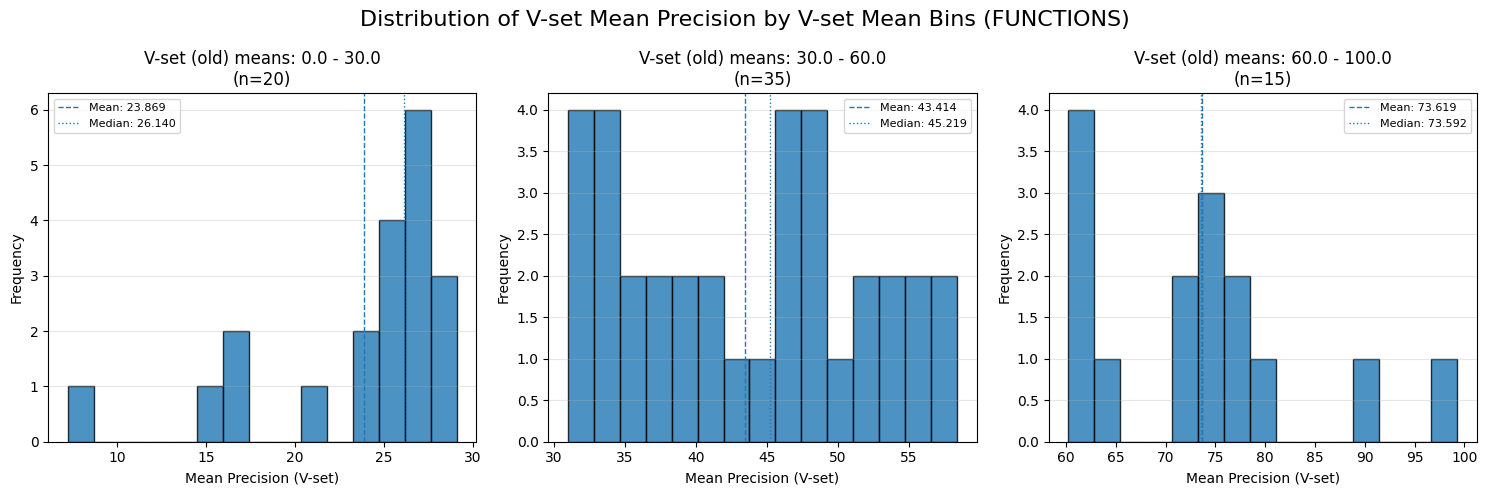

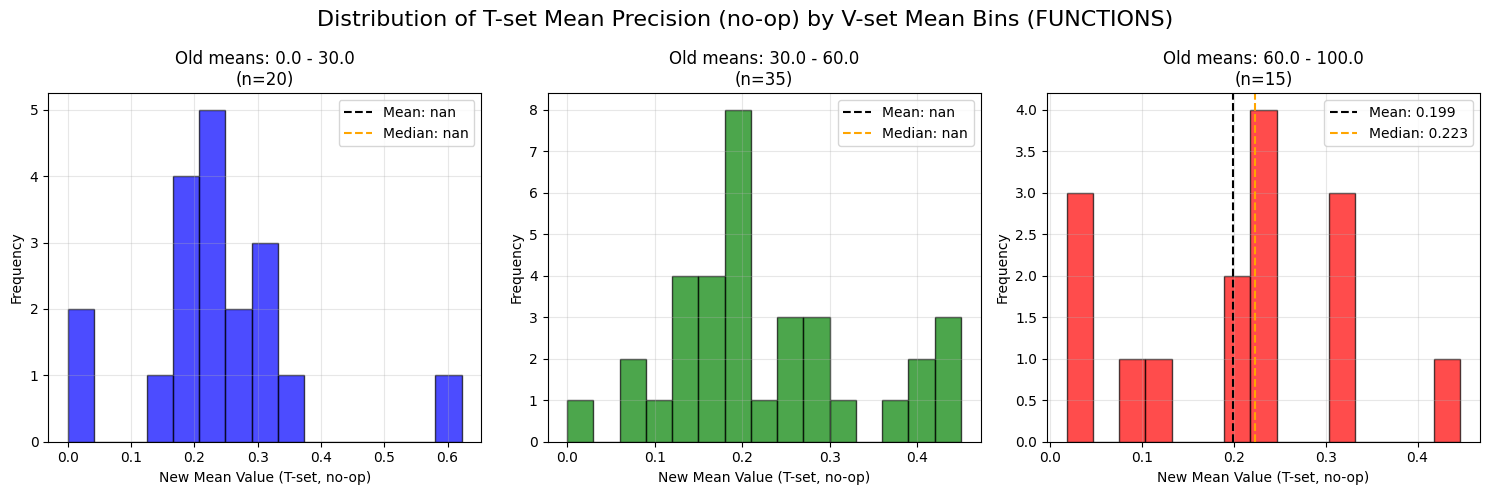

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_41856/1186389172.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_new_means, labels=all_labels)


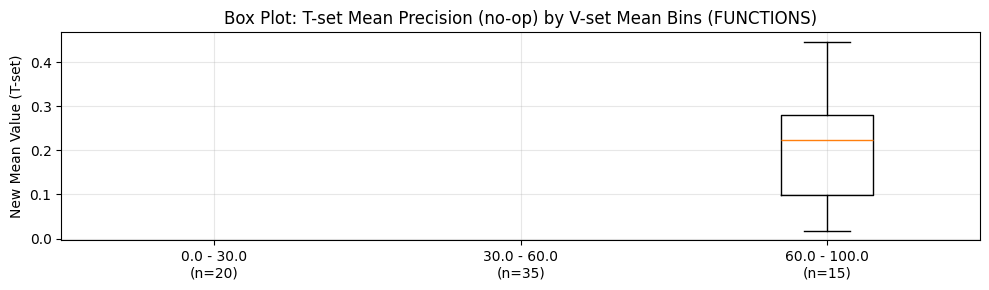

Statistics by Old (V-set) Mean Bin [FUNCTIONS]:

Bin: 0.0 - 30.0
  Count: 20
  T-set mean (no-op) - Mean:   nan
  T-set mean (no-op) - Median: nan
  T-set mean (no-op) - Std:    nan
  T-set mean (no-op) - Min:    nan
  T-set mean (no-op) - Max:    nan
  V-set mean - Mean:           23.8690

Bin: 30.0 - 60.0
  Count: 35
  T-set mean (no-op) - Mean:   nan
  T-set mean (no-op) - Median: nan
  T-set mean (no-op) - Std:    nan
  T-set mean (no-op) - Min:    nan
  T-set mean (no-op) - Max:    nan
  V-set mean - Mean:           43.4140

Bin: 60.0 - 100.0
  Count: 15
  T-set mean (no-op) - Mean:   0.1993
  T-set mean (no-op) - Median: 0.2226
  T-set mean (no-op) - Std:    0.1230
  T-set mean (no-op) - Min:    0.0179
  T-set mean (no-op) - Max:    0.4466
  V-set mean - Mean:           73.6186


: 

: 

: 

: 

In [ ]:
# ==========================================
# FUNCTIONS-ONLY VERSION (CONSISTENT BINS)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# Required to already exist in the environment:
#   results_dist_disc
#   results_dist_disc_Tset_same_seeds_organized
#   select_models_by_criteria(...)
#   recompute_metrics_ignoring_pos_fp(...)

# ---------- 0) Get metrics ONLY via your functions ----------
# Select *all* models on V-set (no filtering)
selected_models_all = select_models_by_criteria(
    results_data=results_dist_disc,
    mean_precision_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(0, 100),
    min_seeds_per_model=1,
    max_models_to_return=len(results_dist_disc),  # include all; prevents sampling cap
    max_zero_precision_seeds=None,
    min_ratio_difference=None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs=None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,
    random_seed=None,
)

# Recompute the same models on T-set with a NO-OP policy (no FP rewriting)
tset_models_keep = recompute_metrics_ignoring_pos_fp(
    selected_models_output=selected_models_all,
    results_data=results_dist_disc_Tset_same_seeds_organized,
    targets=None,           # target nothing
    fp_treatment="keep",    # leave FPs as-is (no-op)
)

# ---------- 1) Build aligned vectors (OLD = V-set means, NEW = T-set means) ----------
old_map = {m["combo_index"]: m.get("mean_precision", np.nan) for m in selected_models_all}
new_map = {m["combo_index"]: m.get("mean_precision", np.nan) for m in tset_models_keep}

# Keep consistent V-set ordering and only models present in both
combo_order = [m["combo_index"] for m in selected_models_all if m["combo_index"] in new_map]

v_mean     = np.array([old_map[c] for c in combo_order], dtype=float)  # OLD = V-set (from selection fn)
v_new_mean = np.array([new_map[c] for c in combo_order], dtype=float)  # NEW = T-set (from recompute fn)

# Drop NaN/Inf in lockstep (keep only pairs where both are finite)
valid = np.isfinite(v_mean) & np.isfinite(v_new_mean)
old = v_mean[valid]
new = v_new_mean[valid]

# ---------- 2) Define identical binning via np.digitize ----------
# Bins: [0,30), [30,60), [60, +inf)
bin_edges = np.array([0.0, 30.0, 60.0, np.inf])
bin_idx = np.digitize(old, bin_edges, right=False) - 1  # -> 0,1,2

range_labels = ['0.0 - 30.0', '30.0 - 60.0', '60.0 - 100.0']
colors = ['blue', 'green', 'red']

# ---------- 3) Figure A: V-set (old) distributions per OLD-mean bin ----------
plt.figure(figsize=(15, 5))
for i, (label, color) in enumerate(zip(range_labels, colors)):
    old_r = old[bin_idx == i]

    ax = plt.subplot(1, 3, i + 1)
    if old_r.size > 0:
        plt.hist(old_r, bins=15, alpha=0.8, edgecolor='black')
        mean_old = float(np.mean(old_r))
        med_old  = float(np.median(old_r))
        plt.axvline(mean_old, linestyle='--', linewidth=1, label=f'Mean: {mean_old:.3f}')
        plt.axvline(med_old,  linestyle=':',  linewidth=1, label=f'Median: {med_old:.3f}')
        plt.title(f'V-set (old) means: {label}\n(n={old_r.size})')
        plt.xlabel('Mean Precision (V-set)'); plt.ylabel('Frequency')
        plt.legend(fontsize=8); plt.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, f'No data in range\n{label}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'V-set (old) means: {label}')
plt.suptitle('Distribution of V-set Mean Precision by V-set Mean Bins (FUNCTIONS)', fontsize=16)
plt.tight_layout(); plt.show()

# ---------- 4) Figure B: T-set (new) distributions per OLD-mean bin ----------
plt.figure(figsize=(15, 5))
for i, (label, color) in enumerate(zip(range_labels, colors)):
    new_r = new[bin_idx == i]

    ax = plt.subplot(1, 3, i + 1)
    if new_r.size > 0:
        plt.hist(new_r, bins=15, alpha=0.7, color=color, edgecolor='black')
        mean_new = float(np.mean(new_r))
        med_new  = float(np.median(new_r))
        plt.axvline(mean_new, color='black', linestyle='--', label=f'Mean: {mean_new:.3f}')
        plt.axvline(med_new,  color='orange', linestyle='--', label=f'Median: {med_new:.3f}')
        plt.title(f'Old means: {label}\n(n={new_r.size})')
        plt.xlabel('New Mean Value (T-set, no-op)'); plt.ylabel('Frequency')
        plt.legend(); plt.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No data in range\n{label}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Old means: {label}')
plt.suptitle('Distribution of T-set Mean Precision (no-op) by V-set Mean Bins (FUNCTIONS)', fontsize=16)
plt.tight_layout(); plt.show()

# ---------- 5) Figure C: Box plot of NEW (T-set) by OLD-mean bins ----------
plt.figure(figsize=(10, 3))
all_new_means, all_labels = [], []
for i, label in enumerate(range_labels):
    new_r = new[bin_idx == i]
    if new_r.size > 0:
        all_new_means.append(new_r)
        all_labels.append(f'{label}\n(n={new_r.size})')
if all_new_means:
    plt.boxplot(all_new_means, labels=all_labels)
    plt.title('Box Plot: T-set Mean Precision (no-op) by V-set Mean Bins (FUNCTIONS)')
    plt.ylabel('New Mean Value (T-set)')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("No non-empty ranges for boxplot.")

# ---------- 6) Stats printout ----------
print("Statistics by Old (V-set) Mean Bin [FUNCTIONS]:")
print("=" * 50)
for i, label in enumerate(range_labels):
    mask = (bin_idx == i)
    new_r = new[mask]; old_r = old[mask]
    if new_r.size > 0:
        print(f"\nBin: {label}")
        print(f"  Count: {new_r.size}")
        print(f"  T-set mean (no-op) - Mean:   {np.mean(new_r):.4f}")
        print(f"  T-set mean (no-op) - Median: {np.median(new_r):.4f}")
        print(f"  T-set mean (no-op) - Std:    {np.std(new_r, ddof=0):.4f}")
        print(f"  T-set mean (no-op) - Min:    {np.min(new_r):.4f}")
        print(f"  T-set mean (no-op) - Max:    {np.max(new_r):.4f}")
        print(f"  V-set mean - Mean:           {np.mean(old_r):.4f}")
    else:
        print(f"\nBin: {label} - No data")


In [ ]:
import numpy as np
from collections import Counter

# --- Inputs expected from your pipeline ---
# v_mean     := np.array of V-set mean_precision aligned to combo_order
# v_new_mean := np.array of T-set mean_precision aligned to the SAME combo_order

v_mean  = np.asarray(v_mean, dtype=float)
v_tmean = np.asarray(v_new_mean, dtype=float)

# --- 1) Overall NaN/Inf stats (separate) ---
old_finite = np.isfinite(v_mean)
new_finite = np.isfinite(v_tmean)

print("=== Overall finiteness (separate) ===")
print(f"V-set: total={v_mean.size}, finite={old_finite.sum()}, non-finite={(~old_finite).sum()}")
print(f"T-set: total={v_tmean.size}, finite={new_finite.sum()}, non-finite={(~new_finite).sum()}")

# Indices of NaNs/Infs separately
old_bad_idx = np.where(~old_finite)[0]
new_bad_idx = np.where(~new_finite)[0]
print("\nIndices non-finite in V-set:", old_bad_idx.tolist())
print("Indices non-finite in T-set:", new_bad_idx.tolist())

# --- 2) Bin *by V-set* only (so bins are defined by old means) ---
# Use identical edges as your plots: [0,30), [30,60), [60, +inf)
bin_edges = np.array([0.0, 30.0, 60.0, np.inf])
# For NaN in v_mean, digitize returns an arbitrary index; protect with finite mask
bin_idx = np.full(v_mean.shape, -1, dtype=int)  # -1 = unbinned (NaN/Inf in V-set)
mask_old_finite = np.isfinite(v_mean)
bin_idx[mask_old_finite] = np.digitize(v_mean[mask_old_finite], bin_edges, right=False) - 1  # 0,1,2

range_labels = ['0.0 - 30.0', '30.0 - 60.0', '60.0 - 100.0']

# --- 3) Count T-set NaNs per V-bin (only where V-set is finite and binned) ---
t_bad_in_bin = Counter()
counts_in_bin = Counter()

for i in range(len(range_labels)):  # bins 0,1,2
    in_bin = (bin_idx == i)
    counts_in_bin[range_labels[i]] = int(in_bin.sum())
    # within this V-bin, how many T-set values are non-finite?
    t_bad_in_bin[range_labels[i]] = int((in_bin & (~new_finite)).sum())

# Also track items with unbinned old (NaN/Inf V-set)
unbinned_count = int((bin_idx == -1).sum())
unbinned_t_bad = int(((bin_idx == -1) & (~new_finite)).sum())

print("\n=== Per V-set bin: T-set non-finite counts ===")
for lbl in range_labels:
    print(f"{lbl}: in_bin={counts_in_bin[lbl]}, T-set non-finite={t_bad_in_bin[lbl]}")
print(f"Unbinned (V-set non-finite): count={unbinned_count}, T-set non-finite among them={unbinned_t_bad}")

# --- 4) (Optional) Show exact indices per bin that have T-set NaN/Inf ---
print("\nIndices with T-set non-finite grouped by V-bin:")
for i, lbl in enumerate(range_labels):
    idxs = np.where((bin_idx == i) & (~new_finite))[0]
    print(f"{lbl}: {idxs.tolist()}")

# If you also have combo_order / combo IDs and want to print those instead of indices:
# combo_order_ids = [...]
# print([combo_order_ids[j] for j in idxs])


=== Overall finiteness (separate) ===
V-set: total=70, finite=70, non-finite=0
T-set: total=70, finite=68, non-finite=2

Indices non-finite in V-set: []
Indices non-finite in T-set: [1, 2]

=== Per V-set bin: T-set non-finite counts ===
0.0 - 30.0: in_bin=20, T-set non-finite=1
30.0 - 60.0: in_bin=35, T-set non-finite=1
60.0 - 100.0: in_bin=15, T-set non-finite=0
Unbinned (V-set non-finite): count=0, T-set non-finite among them=0

Indices with T-set non-finite grouped by V-bin:
0.0 - 30.0: [1]
30.0 - 60.0: [2]
60.0 - 100.0: []


: 

: 

: 

: 

In [ ]:
import numpy as np

# Inputs you already have/aligned:
# combo_order: list of combo_index in the same order as v_mean / v_new_mean
# v_mean:     np.array of V-set mean_precision (same order as combo_order)
# v_new_mean: np.array of T-set mean_precision (same order as combo_order)

# Ensure arrays
v_mean  = np.asarray(v_mean, dtype=float)
v_tmean = np.asarray(v_new_mean, dtype=float)

# Identify non-finite in T-set
t_nonfinite = ~np.isfinite(v_tmean)
idxs = np.where(t_nonfinite)[0]

print(f"T-set non-finite count: {idxs.size} of {v_tmean.size}\n")

# Bin by V-set means for context: [0,30), [30,60), [60, +inf)
bin_edges = np.array([0.0, 30.0, 60.0, np.inf])
# For non-finite old means, mark bin = -1
bin_idx = np.full(v_mean.shape, -1, dtype=int)
mask_old_finite = np.isfinite(v_mean)
bin_idx[mask_old_finite] = np.digitize(v_mean[mask_old_finite], bin_edges, right=False) - 1
range_labels = {0: "0.0 - 30.0", 1: "30.0 - 60.0", 2: "60.0 - 100.0", -1: "UNBINNED (V-set non-finite)"}

def nf_reason(x: float) -> str:
    if np.isnan(x): return "NaN"
    if np.isposinf(x): return "+Inf"
    if np.isneginf(x): return "-Inf"
    return "finite"  # shouldn't happen for non-finite mask, but safe

# Print detailed rows
for j in idxs:
    cid   = combo_order[j] if isinstance(combo_order, (list, tuple)) else j
    old_v = v_mean[j]
    new_v = v_tmean[j]
    b     = bin_idx[j]
    print(f"combo_index={cid:>6} | V-bin={range_labels[b]:>22} | "
          f"V-set mean={old_v!r} | T-set mean={new_v!r} ({nf_reason(new_v)})")

# Optional: group by V-bin
print("\nSummary by V-bin for T-set non-finite:")
for b in (-1, 0, 1, 2):
    count_b = int(np.sum((bin_idx == b) & t_nonfinite))
    print(f"  {range_labels[b]:>22}: {count_b}")


T-set non-finite count: 2 of 70

combo_index=     1 | V-bin=            0.0 - 30.0 | V-set mean=np.float64(29.0650406504065) | T-set mean=np.float64(nan) (NaN)
combo_index=     2 | V-bin=           30.0 - 60.0 | V-set mean=np.float64(38.319088319088316) | T-set mean=np.float64(nan) (NaN)

Summary by V-bin for T-set non-finite:
  UNBINNED (V-set non-finite): 0
              0.0 - 30.0: 1
             30.0 - 60.0: 1
            60.0 - 100.0: 0


: 

: 

: 

: 

In [ ]:
tset_models_keep[1]

{'combo_index': 1,
 'parameters': {'binary_0_1_cutoff_ret_rate_percentage': 0.1,
  'learning_rate': 0.05,
  'num_epochs': 150,
  'batch_size': 50,
  'use_bidirectional': False,
  'lag': 8,
  'input_size': 12,
  'hidden_size': 35,
  'num_layers': 6,
  'use_monthly_dfs_only': True,
  'use_binary_0_1_retRate': False,
  'use_custom_loss_function_BCE_THRESH': True,
  'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
  'use_LOW_weights_for_BCE_custom_loss': True,
  'pred_threshold_sigmoid01_up': None,
  'use_binary_neg1_1': False,
  'use_ret_rate': False,
  'use_print_acc': False,
  'use_dropout': False,
  'use_class_weighting': True,
  'is_deterministic': True,
  'seed_num': 42,
  'use_existing_lagged_data': True,
  'use_dynamic_weights': False,
  'use_binary_0_1_retRate_custom_neg': False,
  'use_binary_0_1_retRate_custom_pos': True,
  'POS_weight_multiplier': 1,
  'use_rolling_fixed_train_size': False,
  'use_existing_initial_weights': False,
  'state_dict': None,
  'use_USO_wtic

: 

: 

: 

: 

In [ ]:
results_dist_disc_Tset_same_seeds_organized[1]


seed_prec_ups = []
for i in results_dist_disc_Tset_same_seeds_organized[1]["per_seed_all_results"]:
    prec = i["result_entry"]["cv_sets"]["overall_metrics"]["precision_up"]
    seed_prec_ups.append(prec)





#   'num_epochs': 150,
#   'batch_size': 50,
#   'use_bidirectional': False,
#   'lag': 8,
#   'input_size': 12,
#   'hidden_size': 35,
#   'num_layers': 6,
#   'use_monthly_dfs_only': True,
#   'use_binary_0_1_retRate': False,
#   'use_custom_loss_function_BCE_THRESH': True,
#   'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
#   'use_LOW_weights_for_BCE_custom_loss': True,
#   'pred_threshold_sigmoid01_up': None,
#   'use_binary_neg1_1': False,
#   'use_ret_rate': False,
#   'use_print_acc': False,
#   'use_dropout': False,
#   'use_class_weighting': True,
#   'is_deterministic': True,
#   'seed_num': 42,
#   'use_existing_lagged_data': True,
#   'use_dynamic_weights': False,
#   'use_binary_0_1_retRate_custom_neg': False,
#   'use_binary_0_1_retRate_custom_pos': True,
#   'POS_weight_multiplier': 1,
#   'use_rolling_fixed_train_size': False,
#   'use_existing_initial_weights': False,
#   'state_dict': None,
#   'use_USO_wticoncat_predictor_WEEKLY_END_MO': False,
#   'use_UCO_wticoncat_predictor_WEEKLY_END_MO': False,
#   'use_HUC_wticoncat_predictor_WEEKLY_END_MO': False,
#   'use_HOD_wticoncat_predictor_WEEKLY_END_MO': True,
#   'use_CRUD_wticoncat_predictor_WEEKLY_END_MO': False,
#   'use_SCO_wticoncat_predictor_WEEKLY_END_MO': False,
#   'train_start_month': '2008-01',
#   'val_start_month': '2022-01',
#   'val_end_month': '2022-12',
#   'num_preds_per_fold': 3},
#  'per_seed_all_results': [{'seed': 39668,
#    'result_entry': {'combo_number': 72,
#     'parameters': {'binary_0_1_cutoff_ret_rate_percentage': 0.1,
#      'learning_rate': 0.05,
#      'num_epochs': 150,
#      'batch_size': 50,
#      'use_bidirectional': False,
#      'lag': 8,
#      'input_size': 12,
#      'hidden_size': 35,
#      'num_layers': 6,
#      'use_monthly_dfs_only': True,
#      'use_binary_0_1_retRate': False,
#      'use_custom_loss_function_BCE_THRESH': True,
#      'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
#      'use_LOW_weights_for_BCE_custom_loss': True,
#      'pred_threshold_sigmoid01_up': None,
#      'use_binary_neg1_1': False,
#      'use_ret_rate': False,
#      'use_print_acc': False,
#      'use_dropout': False,
#      'use_class_weighting': True,
#      'is_deterministic': True,
#      'seed_num': 39668,
#      'use_existing_lagged_data': True,
#      'use_dynamic_weights': False,
#      'use_binary_0_1_retRate_custom_neg': False,
#      'use_binary_0_1_retRate_custom_pos': True,
#      'POS_weight_multiplier': 1,
#      'use_rolling_fixed_train_size': False,
#      'use_existing_initial_weights': False,
#      'state_dict': None,
#      'use_USO_wticoncat_predictor_WEEKLY_END_MO': False,
#      'use_UCO_wticoncat_predictor_WEEKLY_END_MO': False,
#      'use_HUC_wticoncat_predictor_WEEKLY_END_MO': False,
#      'use_HOD_wticoncat_predictor_WEEKLY_END_MO': True,
#      'use_CRUD_wticoncat_predictor_WEEKLY_END_MO': False,
#      'use_SCO_wticoncat_predictor_WEEKLY_END_MO': False,
#      'train_start_month': '2008-01',
#      'val_start_month': '2022-01',
#      'val_end_month': '2022-12',
#      'num_preds_per_fold': 3},
#     'cv_sets': {'set_1': {'accuracy': 100.0,
#       'precision_up': None,
#       'recall_up': None,
#       'precision_down': 100.0,
#       'recall_down': 100.0},
#      'set_2': {'accuracy': 100.0,
#       'precision_up': None,
#       'recall_up': None,
#       'precision_down': 100.0,
#       'recall_down': 100.0},
#      'set_3': {'accuracy': 66.66666666666666,
#       'precision_up': None,
#       'recall_up': 0,
#       'precision_down': 66.66666666666666,
#       'recall_down': 100.0},
#      'set_4': {'accuracy': 66.66666666666666,
#       'precision_up': None,
#       'recall_up': 0,
#       'precision_down': 66.66666666666666,
#       'recall_down': 100.0},
#      'avg_across_all_sets': {'accuracy': 83.33333333333331,
#       'precision_up': None,
#       'recall_up': 0.0,
#       'precision_down': 83.33333333333331,
#       'recall_down': 100.0},
#      'overall_metrics': {'accuracy': 83.33333333333334,
#       'precision_up': None,
#       'recall_up': 0,
#       'precision_down': 83.33333333333334,
#       'recall_down': 100.0}},
#     'all_preds': [[0.47922447323799133,
#       0.47922250628471375,
#       0.4791865944862366],
#      [0.4906228184700012, 0.4906228184700012, 0.4906228184700012],
#      [0.48627492785453796, 0.48627492785453796, 0.48627492785453796],
#      [0.49626362323760986, 0.4962632656097412, 0.49626314640045166]],
#     'all_actuals': [[0.0, 0.0, 0.0],
#      [0.0, 0.0, 0.0],
#      [0.0, 0.0, 1.0],
#      [0.0, 1.0, 0.0]],
#     'raw_actuals': [[-0.23493562231759657,
#       -0.17536183103332204,
#       -0.4469387755102041],
#      [0.0354243542435424, -0.2302209550962223, 0.026851851851851682],
#      [0.06672678088367912, 0.01014370245139462, 0.28744769874477005],
#      [-0.20685732856678574, 0.15017414464249113, -0.044947155919724424]],
#     'Y_vals_dates_LIST': [['2022-01-28T00:00:00',
#       '2022-02-25T00:00:00',
#       '2022-03-25T00:00:00'],
#      ['2022-04-29T00:00:00', '2022-05-27T00:00:00', '2022-06-24T00:00:00'],
#      ['2022-07-29T00:00:00', '2022-08-26T00:00:00', '2022-09-30T00:00:00'],
#      ['2022-10-28T00:00:00', '2022-11-25T00:00:00', '2022-12-30T00:00:00']]}},
#   {'seed': 2715,

: 

: 

: 

: 

In [ ]:
for i in seed_prec_ups:
    if not i == None:
        print(i)




: 

: 

: 

: 